# Previsão de Preços de Imóveis no Airbnb em Sydney

Imagine que um anfitrião possui um imóvel em **Bondi Beach**, Sydney, Austrália, cobra atualmente **US$ 500 por noite** e deseja saber se esse valor está de acordo com o mercado.

Para responder a essa pergunta, construiremos um **modelo de regressão supervisionada**, capaz de aprender a relação entre as características dos imóveis — como localização, número de quartos, avaliações e tipo de propriedade — e o preço da diária.

Assim, este notebook seguirá o fluxo padrão de um projeto de **Machine Learning**, semelhante aos desenvolvidos nas aulas anteriores.:

1. **Configuração do ambiente** — bibliotecas e opções globais.
2. **Obtenção dos dados** — carregamento do dataset público de anúncios do Airbnb em Sydney.
3. **Primeira inspeção** — estrutura, tipos e colunas relevantes.
4. **Limpeza dos dados** — conversão de tipos, tratamento de valores ausentes e outliers.
5. **Estatística descritiva e análise exploratória (EDA)** — distribuições, correlações e mapas.
6. **Divisão treino/teste estratificada** — separando os dados antes de qualquer decisão de modelagem.
7. **Engenharia de atributos** — criação de variáveis mais informativas.
8. **Pipeline de pré-processamento** — imputação, padronização e codificação categórica.
9. **Modelos supervisionados de linha de base** — regressão linear e árvore de decisão.
10. **Regularização** — Ridge (L2), Lasso (L1) e Elastic Net (L1+L2).
11. **Modelos de ensemble e ajuste de hiperparâmetros** — Random Forest com busca em grade/aleatória.
12. **Comparação final de modelos via validação cruzada**.
13. **Avaliação no conjunto de teste**.
14. **Importância das variáveis**.
15. **Aplicação prática** — estimando o preço justo para o imóvel de Bondi Beach.
16. **Resumo**.

> **Nota metodológica importante:** ao longo do notebook, sempre que possível, colocamos o
> pré-processamento (imputação, padronização, codificação) **dentro** do mesmo `Pipeline` do
> scikit-learn que é validado por validação cruzada. Isso evita **vazamento de dados** (*data
> leakage*): se ajustássemos o `StandardScaler` ou o `SimpleImputer` usando o conjunto de treino
> inteiro *antes* de dividir em folds de validação cruzada, cada fold de validação "veria"
> estatísticas (média, desvio-padrão, mediana) calculadas com dados que, na prática, não deveriam
> estar disponíveis no momento do treino daquele fold. O resultado seria uma estimativa de erro
> ligeiramente **otimista demais**. Usar um `Pipeline` garante que cada fold refaça o ajuste do
> pré-processamento apenas com os dados de treino daquele fold.


## 1. Configuração do ambiente

Começamos importando as bibliotecas que serão usadas no notebook:

- **pandas / numpy**: manipulação de dados tabulares e arrays numéricos;
- **matplotlib / seaborn**: visualização de dados;
- **scikit-learn**: pré-processamento, modelos de regressão, validação cruzada e métricas.

Também fixamos uma *seed* aleatória (`random_state`) em todos os pontos do notebook em que há
algum componente estocástico (divisão treino/teste, inicialização de modelos, buscas de
hiperparâmetros). Isso torna o notebook **reprodutível**: rodar tudo novamente do início ao fim
produz exatamente os mesmos números.

In [37]:
# Bibliotecas de manipulação de dados
import re
import warnings

import numpy as np
import pandas as pd

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: pré-processamento
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# scikit-learn: divisão de dados e validação cruzada
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    StratifiedShuffleSplit,
    cross_validate,
)

# scikit-learn: modelos supervisionados
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# scikit-learn: métricas de avaliação
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

from scipy.stats import randint

# Semente global, usada sempre que um método aceita `random_state`
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Faz com que transformadores do sklearn (ColumnTransformer, Pipeline, etc.)
# devolvam DataFrames do pandas em vez de arrays numpy "crus" -- isso facilita
# muito inspecionar nomes de colunas depois de imputação/codificação.
set_config(transform_output="pandas")

# Ajustes estéticos para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.labelsize"] = 12

# Suprime avisos de depreciação que não afetam o resultado, para manter a saída limpa
warnings.filterwarnings("ignore")
pd.options.display.max_columns = None

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


## 2. Obtenção dos dados

Vamos usar o mesmo conjunto de dados público de anúncios do Airbnb em Sydney (dados no estilo *Inside Airbnb*, com uma linha por
anúncio e dezenas de colunas descritivas). O arquivo é carregado de um repositório público no
GitHub; se ele já tiver sido baixado antes (e salvo localmente em `datasets/sydney_airbnb.csv`),
reaproveitamos a cópia local para não precisar baixar ~100 MB novamente.

In [38]:
from pathlib import Path

GITHUB_URL = (
    "https://raw.githubusercontent.com/Finance-781/FinML/master/"
    "Lecture%202%20-%20End-to-End%20ML%20Project%20/Practice/datasets/sydney_airbnb.csv"
)
LOCAL_PATH = Path("datasets/sydney_airbnb.csv")

if LOCAL_PATH.is_file():
    print("Arquivo local encontrado, carregando de disco...")
    df_raw = pd.read_csv(LOCAL_PATH, low_memory=False)
else:
    print("Baixando dados do GitHub (pode levar 1-2 minutos)...")
    LOCAL_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_raw = pd.read_csv(GITHUB_URL, low_memory=False)
    df_raw.to_csv(LOCAL_PATH, index=False)
    print("Concluído e salvo em cache local.")

print(f"Dimensões do dataset bruto: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")

Arquivo local encontrado, carregando de disco...
Dimensões do dataset bruto: 27070 linhas x 84 colunas


## 3. Primeira inspeção dos dados

O arquivo bruto tem dezenas de colunas (URLs de fotos, descrições em texto livre, etc.) que não
são relevantes para prever preço numericamente. Vamos primeiro dar uma olhada geral e depois
selecionar apenas as colunas que fazem sentido para o modelo.

In [39]:
df_raw.head()

,id,listing_url,name,summary,space,description,neighborhood_overview,notes,transit,access,interaction,house_rules,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,street,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,city,state,zipcode,market,smart_location,country_code,country,latitude,longitude,is_location_exact,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,amenities,square_feet,price,weekly_price,monthly_price,security_deposit,cleaning_fee,guests_included,extra_people,minimum_nights,maximum_nights,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,11156,https://www.airbnb.com/rooms/11156,An Oasis in the City,Very central to the city which can be reached ...,Potts Pt. is a vibrant and popular inner-city...,Very central to the city which can be reached ...,"It is very close to everything and everywhere,...","$150.00 key security deposit, refundable on re...",It is 7 minutes walk to the Kings Cross.train ...,Kitchen & laundry facilities. Shared bathroom.,As much as they want.,Be considerate. No showering after 2330h.,https://a0.muscache.com/im/pictures/2797669/17...,40855,https://www.airbnb.com/users/show/40855,Colleen,23/09/09,"Potts Point, New South Wales, Australia","Recently retired, I've lived & worked on 4 con...",within a day,67%,t,https://a0.muscache.com/im/users/40855/profile...,https://a0.muscache.com/im/users/40855/profile...,Potts Point,1.0,1.0,"['email', 'phone', 'reviews']",t,f,"Potts Point, NSW, Australia",Potts Point,Sydney,NaN,Potts Point,NSW,2011,Sydney,"Potts Point, Australia",AU,Australia,-33.869168,151.226562,t,Apartment,Private room,1,NaN,1.0,1.0,Real Bed,"{TV,Kitchen,Elevator,""Buzzer/wireless intercom...",NaN,$65.00,NaN,NaN,NaN,NaN,1,$0.00,2,180,4 weeks ago,t,9,39,69,339,177,5/12/09,1/07/18,92.0,9.0,9.0,10.0,10.0,10.0,9.0,f,moderate,f,f,1,1.69
1,12351,https://www.airbnb.com/rooms/12351,Sydney City & Harbour at the door,Come stay with Vinh & Stuart (Awarded as one o...,"We're pretty relaxed hosts, and we fully appre...",Come stay with Vinh & Stuart (Awarded as one o...,"Pyrmont is an inner-city village of Sydney, on...",We've a few reasons for the 6.00pm arrival tim...,Our home is centrally located and an easy walk...,We look forward to welcoming you just as we wo...,As much or as little as you like. We live here...,We look forward to welcoming you to stay you j...,https://a0.muscache.com/im/pictures/763ad5c8-c...,17061,https://www.airbnb.com/users/show/17061,Stuart,14/05/09,"Sydney, New South Wales, Australia","G'Day from Australia!\r\n\r\nHe's Vinh, and I'...",within an hour,100%,f,https://a0.muscache.com/im/users/17061/profile...,https://a0.muscache.com/im/users/17061/profile...,Pyrmont,2.0,2.0,"['email', 'phone', 'manual_online', 'reviews',...",t,t,"Pyrmont, NSW, Australia",Pyrmont,Sydney,NaN,Pyrmont,NSW,2009,Sydney,"Pyrmont, Australia",AU,Australia,-33.865153,151.191896,t,Townhouse,Private room,2,1.0,1.0,1.0,Real Bed,"{TV,Internet,Wifi,""Air conditioning"",""Paid par...",NaN,$98.00,$800.00,NaN,$0.00,$55.00,2,$395.00,2,7,yesterday,t,13,30,45,188,468,24/07/10,27/06/18,95.0,10.0,9.0,10.0,10.0,10.0,10.0,f,strict_14_with_grace_period,t,t,2,4.83
2,14250,https://www.airbnb.com/rooms/14250,Manly Harbour House,"Beautifully renovated, spacious and quiet, our...",Our home is a thirty minute walk along the sea...,"Beautifully reno

In [40]:
# Lista completa de colunas disponíveis no dataset bruto
df_raw.columns.tolist()

['id',
 'listing_url',
 'name',
 'summary',
 'space',
 'description',
 'neighborhood_overview',
 'notes',
 'transit',
 'access',
 'interaction',
 'house_rules',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'street',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'city',
 'state',
 'zipcode',
 'market',
 'smart_location',
 'country_code',
 'country',
 'latitude',
 'longitude',
 'is_location_exact',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'bed_type',
 'amenities',
 'square_feet',
 'price',
 'weekly_price',
 'monthly_price',
 'security_deposit',
 'cleaning_fee',
 'guests_included',
 'extra_peopl

Selecionamos um subconjunto de colunas com potencial preditivo direto sobre o preço:
localização (`longitude`, `latitude`, `city`), características físicas do imóvel
(`accommodates`, `bathrooms`, `bedrooms`, `beds`, `property_type`, `room_type`), características
comerciais (`cleaning_fee`, `security_deposit`, `minimum_nights`, `availability_365`,
`cancellation_policy`) e reputação do anfitrião (`review_scores_rating`, `number_of_reviews`,
`host_is_superhost`, `host_identity_verified`, `host_since`).

Colunas de texto livre (descrição, regras da casa, etc.), identificadores e URLs foram
deliberadamente descartadas: elas exigiriam técnicas de processamento de linguagem natural que
fogem do escopo deste estudo (regressão sobre atributos estruturados).

In [41]:
FEATURE_COLUMNS = [
    "price",                    # variável-alvo (o que queremos prever)
    "city",
    "longitude",
    "latitude",
    "review_scores_rating",
    "number_of_reviews",
    "minimum_nights",
    "security_deposit",
    "cleaning_fee",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "property_type",
    "room_type",
    "availability_365",
    "host_identity_verified",
    "host_is_superhost",
    "host_since",
    "cancellation_policy",
]

df = df_raw[FEATURE_COLUMNS].copy()
print(f"Dimensões após seleção de colunas: {df.shape}")
df.head()

Dimensões após seleção de colunas: (27070, 20)


,price,city,longitude,latitude,review_scores_rating,number_of_reviews,minimum_nights,security_deposit,cleaning_fee,accommodates,bathrooms,bedrooms,beds,property_type,room_type,availability_365,host_identity_verified,host_is_superhost,host_since,cancellation_policy
0,$65.00,Potts Point,151.226562,-33.869168,92.0,177,2,NaN,NaN,1,NaN,1.0,1.0,Apartment,Private room,339,f,t,23/09/09,moderate
1,$98.00,Pyrmont,151.191896,-33.865153,95.0,468,2,$0.00,$55.00,2,1.0,1.0,1.0,Townhouse,Private room,188,t,f,14/05/09,strict_14_with_grace_period
2,$469.00,Balgowlah,151.261722,-33.800929,100.0,1,5,$900.00,$100.00,6,3.0,3.0,3.0,House,Entire home/apt,168,t,f,20/11/09,strict_14_with_grace_period
3,$63.00,Redfern,151.200450,-33.890765,89.0,172,2,NaN,NaN,2,1.0,1.0,1.0,Apartment,Private room,215,t,f,30/11/09,moderate
4,$39.00,Redfern,151.200896,-33.889667,90.0,147,2,NaN,NaN,1,2.0,1.0,1.0,Apartment,Shared room,287,t,f,30/11/09,moderate


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27070 entries, 0 to 27069
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   price                   27070 non-null  str    
 1   city                    27037 non-null  str    
 2   longitude               27070 non-null  float64
 3   latitude                27070 non-null  float64
 4   review_scores_rating    19512 non-null  float64
 5   number_of_reviews       27070 non-null  int64  
 6   minimum_nights          27070 non-null  int64  
 7   security_deposit        16722 non-null  str    
 8   cleaning_fee            19250 non-null  str    
 9   accommodates            27070 non-null  int64  
 10  bathrooms               27048 non-null  float64
 11  bedrooms                27062 non-null  float64
 12  beds                    27037 non-null  float64
 13  property_type           27070 non-null  str    
 14  room_type               27070 non-null  str    
 

## 4. Limpeza dos dados

Esta etapa costuma ser a mais trabalhosa (e mais importante!) de um projeto de ML aplicado.
Vamos resolver, em ordem:

1. Campos monetários (`price`, `cleaning_fee`, `security_deposit`) que vieram como texto
   (ex.: `"$1,200.00"`) e precisam virar números.
2. A coluna de data `host_since`.
3. Variáveis binárias texto (`"t"`/`"f"`) que devem virar `1`/`0`.
4. Outliers extremos de preço.
5. Valores ausentes.
6. Categorias raras (poucas ocorrências), que atrapalham a validação cruzada e o one-hot
   encoding.

### 4.1 Campos monetários

Os campos de valores monetários no arquivo original vêm como texto, com o símbolo `$` e
separador de milhar (`,`), por exemplo `"$1,250.00"`. Usamos uma expressão regular para manter
apenas dígitos e ponto decimal, convertendo o resultado para `float`. Valores em branco são
tratados como `0` (ausência de taxa de limpeza ou de depósito de segurança, por exemplo, é comum
e significa que o anfitrião simplesmente não cobra essa taxa).

In [43]:
import pandas as pd
import re

# Colunas que contêm valores monetários
money_columns = ["price", "cleaning_fee", "security_deposit"]

def converter_para_float(valor):
    """Converte um valor monetário, como '$1,250.00', para 1250.0."""
    # Valores ausentes serão representados por 0.0
    if pd.isna(valor):
        return 0.0
    # Garante que o valor seja tratado como texto
    valor = str(valor)
    # Remove espaços no começo e no final
    valor = valor.strip()
    # Remove símbolos monetários, letras e vírgulas.
    # Exemplo: "$1,250.00" → "1250.00"
    valor_limpo = re.sub(r"[^0-9.]", "", valor)
    # Se não restar nenhum número, retorna 0.0
    if valor_limpo == "":
        return 0.0
    # Converte o texto limpo para um número decimal
    return float(valor_limpo)

# Aplica a função a cada coluna monetária
for coluna in money_columns:
    df[coluna] = df[coluna].apply(converter_para_float)

# Confere as estatísticas das colunas após a conversão
df[money_columns].describe()

,price,cleaning_fee,security_deposit
count,27070.000000,27070.000000,27070.000000
mean,209.278796,66.674178,305.766679
std,304.336271,88.246098,591.491850
min,0.000000,0.000000,0.000000
25%,80.000000,0.000000,0.000000
50%,135.000000,40.000000,0.000000
75%,229.000000,100.000000,450.000000
max,12999.000000,999.000000,7000.000000


### 4.2 Data de ingresso do anfitrião (`host_since`)

Convertida para o tipo `datetime`. O formato original é `dd/mm/aa` (ex.: `23/09/09`), então
informamos o formato explicitamente para evitar ambiguidades (por exemplo, `03/04/09` poderia
ser interpretado como 3 de abril ou 4 de março, dependendo da convenção).

In [44]:
df["host_since"] = pd.to_datetime(df["host_since"], format="%d/%m/%y")
df["host_since"].describe()

count                         27035
mean     2015-02-13 15:04:28.851488
min             2009-02-22 00:00:00
25%             2014-01-12 00:00:00
50%             2015-04-05 00:00:00
75%             2016-04-20 00:00:00
max             2018-01-13 00:00:00
Name: host_since, dtype: object

### 4.3 Variáveis binárias

`host_identity_verified` e `host_is_superhost` vêm como texto `"t"`/`"f"` (True/False). Convertemos para
`1`/`0`, o que é necessário para qualquer modelo numérico. Note que usamos `.map(...)`, que
preserva `NaN` para valores ausentes (em vez de forçá-los silenciosamente para `0`). Isso será
tratado corretamente mais adiante, na etapa de imputação.

In [45]:
df["host_identity_verified"] = df["host_identity_verified"].map({"t": 1, "f": 0})
df["host_is_superhost"] = df["host_is_superhost"].map({"t": 1, "f": 0})
df[["host_identity_verified", "host_is_superhost"]].head()

,host_identity_verified,host_is_superhost
0,0.0,1.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0


### 4.4 Outliers no preço

Vamos olhar a distribuição do preço. Um boxplot é uma forma rápida de visualizar a mediana, os
quartis e os pontos que se destoam muito do resto (candidatos a outlier).

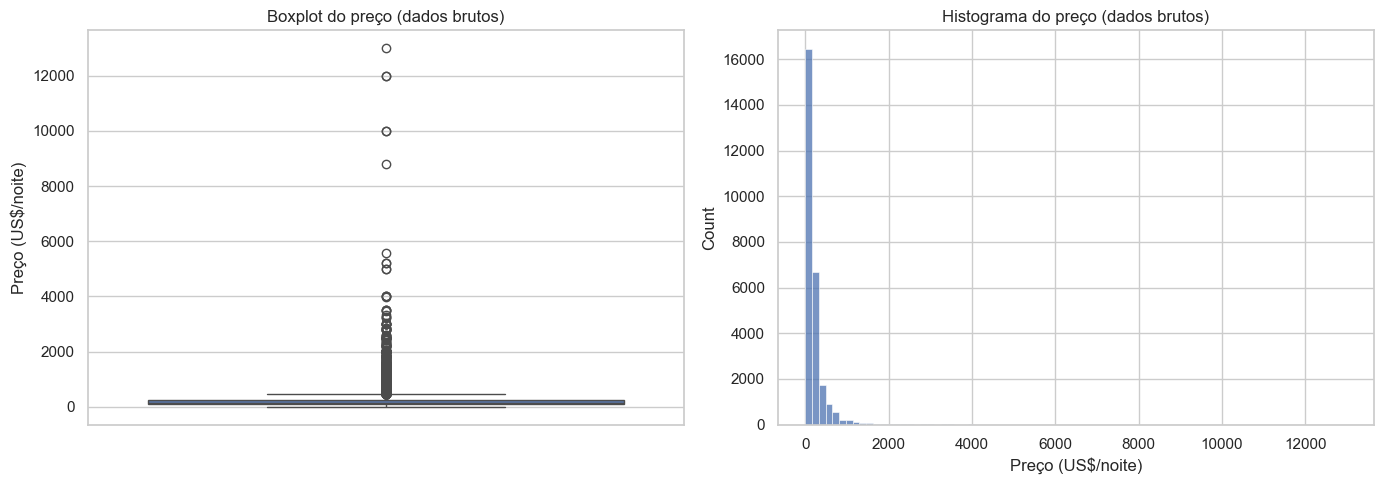

Assimetria (skewness):  13.81
Curtose (kurtosis):     413.43


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df["price"], ax=axes[0])
axes[0].set_title("Boxplot do preço (dados brutos)")
axes[0].set_ylabel("Preço (US$/noite)")

sns.histplot(df["price"], bins=80, ax=axes[1])
axes[1].set_title("Histograma do preço (dados brutos)")
axes[1].set_xlabel("Preço (US$/noite)")

plt.tight_layout()
plt.show()

print(f"Assimetria (skewness):  {df['price'].skew():.2f}")
print(f"Curtose (kurtosis):     {df['price'].kurtosis():.2f}")

A distribuição é fortemente assimétrica à direita (*skewness* bem acima de zero) e tem
cauda pesada (curtose muito alta): a grande maioria dos imóveis custa entre 50 e 300 dólares
por noite, mas existem alguns poucos anúncios com preços extremos (na casa dos milhares de
dólares) que distorcem médias, desvios-padrão e podem dominar a função de custo
de um modelo de regressão treinado por mínimos quadrados.

Uma abordagem simples e robusta é **cortar a cauda superior**: mantemos apenas os anúncios com
preço abaixo do percentil 99,5%, e descartamos também os poucos anúncios com preço 0 (que
provavelmente representam anúncios sem preço definido, e não imóveis realmente gratuitos).

In [50]:
p995 = df["price"].quantile(0.995)
print(f"Percentil 99.5% do preço: US$ {p995:.2f}")
print(f"Média:   US$ {df['price'].mean():.2f}")
print(f"Mediana: US$ {df['price'].median():.2f}")

n_before = len(df)
df = df[(df["price"] > 0) & (df["price"] < p995)].reset_index(drop=True)
n_after = len(df)

print(f"\nLinhas removidas: {n_before - n_after} ({(n_before - n_after) / n_before:.2%} do total)")
print(f"Nova assimetria (skewness): {df['price'].skew():.2f}")

Percentil 99.5% do preço: US$ 1250.00
Média:   US$ 196.14
Mediana: US$ 132.00

Linhas removidas: 146 (0.54% do total)
Nova assimetria (skewness): 2.53


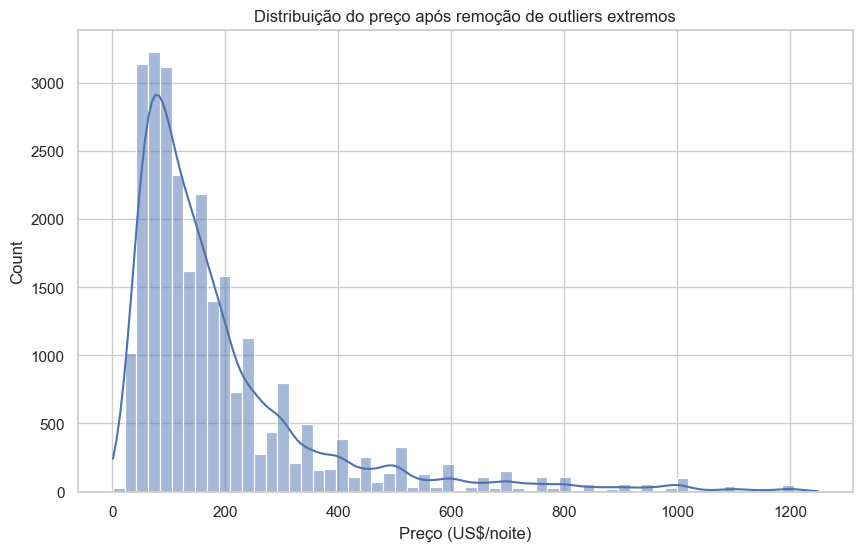

In [51]:
sns.histplot(df["price"], bins=60, kde=True)
plt.title("Distribuição do preço após remoção de outliers extremos")
plt.xlabel("Preço (US$/noite)")
plt.show()

### 4.5 Valores ausentes

Vamos checar quais colunas ainda têm valores ausentes depois das transformações acima.

In [52]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"n_ausentes": missing, "% do total": missing_pct})

,n_ausentes,% do total
review_scores_rating,7381,27.57
host_identity_verified,34,0.13
host_is_superhost,34,0.13
host_since,34,0.13
beds,33,0.12
city,32,0.12
bathrooms,22,0.08
bedrooms,8,0.03


A coluna com mais valores ausentes é `review_scores_rating` (nota média das avaliações).
Vale investigar **por que** ela está ausente antes de simplesmente imputar um valor: será que é
aleatório, ou existe um padrão?

In [53]:
sem_nota = df["review_scores_rating"].isnull()

print("Estatísticas de 'number_of_reviews' quando a nota ESTÁ ausente:")
print(df.loc[sem_nota, "number_of_reviews"].describe())

print("\nEstatísticas de 'number_of_reviews' quando a nota NÃO está ausente:")
print(df.loc[~sem_nota, "number_of_reviews"].describe())

Estatísticas de 'number_of_reviews' quando a nota ESTÁ ausente:
count    7381.000000
mean        0.136702
std         0.720120
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        38.000000
Name: number_of_reviews, dtype: float64

Estatísticas de 'number_of_reviews' quando a nota NÃO está ausente:
count    19394.000000
mean        19.466484
std         33.675703
min          1.000000
25%          2.000000
50%          6.000000
75%         21.000000
max        468.000000
Name: number_of_reviews, dtype: float64


O padrão é claro: quando `review_scores_rating` está ausente, o número de avaliações é
quase sempre **zero**. Ou seja, a nota não está "faltando aleatoriamente", ela simplesmente não
existe porque **o imóvel ainda não recebeu nenhuma avaliação** (é um anúncio novo, ou pouco
popular). Isso é um valor ausente do tipo *"não aplicável"*, não um erro de coleta.

Diante disso, vamos:

1. Criar uma variável indicadora `has_reviews` (1 se o imóvel já tem alguma avaliação, 0 caso
   contrário), isso preserva a informação de que o imóvel é "novo no mercado", que é
   potencialmente preditiva por si só.
2. Imputar os valores ausentes de `review_scores_rating` pela **mediana** dentro do pipeline de
   pré-processamento (feito mais adiante, de forma consistente entre treino e teste).

As demais colunas com poucos valores ausentes (`bathrooms`, `bedrooms`, `beds`,
`host_identity_verified`, `host_is_superhost`, `host_since`) representam uma fração muito
pequena da base e também serão tratadas por imputação de mediana/moda no pipeline, não há
necessidade de descartar essas linhas.

### 4.6 Categorias raras

Variáveis categóricas com muitas categorias distintas, algumas delas com pouquíssimas
observações, são problemáticas para a validação cruzada: uma categoria que aparece só 1 ou 2
vezes no dataset inteiro pode, por azar, cair inteiramente em um fold de teste e nunca aparecer
no treino (ou vice-versa), o que quebra o one-hot encoding (ver adiante) e deixa a avaliação
instável. Vamos:

- Manter apenas os **15 bairros (`city`) mais frequentes**: o cliente está interessado em Bondi
  Beach, mas manter vários bairros populares nos dá mais dados e generaliza melhor;
- Remover **tipos de propriedade (`property_type`) muito raros** (10 ocorrências ou menos).

In [54]:
print("Contagem de anúncios por bairro (top 20):")
print(df["city"].value_counts().head(20))

Contagem de anúncios por bairro (top 20):
city
Bondi Beach       1666
Manly              949
Surry Hills        919
Bondi              784
Randwick           683
Sydney             680
Coogee             673
Darlinghurst       658
North Bondi        624
Newtown            490
Redfern            479
Paddington         443
Maroubra           443
Bondi Junction     415
Potts Point        379
Mosman             375
Bronte             361
Pyrmont            306
Waterloo           299
Glebe              259
Name: count, dtype: int64


In [55]:
TOP_N_CITIES = 15
top_cities = df["city"].value_counts().head(TOP_N_CITIES).index.tolist()

n_before = len(df)
df = df[df["city"].isin(top_cities)].reset_index(drop=True)
print(f"Linhas removidas ao filtrar para os {TOP_N_CITIES} bairros mais comuns: {n_before - len(df)}")
print(f"Bairros mantidos: {top_cities}")

Linhas removidas ao filtrar para os 15 bairros mais comuns: 16490
Bairros mantidos: ['Bondi Beach', 'Manly', 'Surry Hills', 'Bondi', 'Randwick', 'Sydney', 'Coogee', 'Darlinghurst', 'North Bondi', 'Newtown', 'Redfern', 'Paddington', 'Maroubra', 'Bondi Junction', 'Potts Point']


In [56]:
print("Contagem de anúncios por tipo de propriedade:")
print(df["property_type"].value_counts())

Contagem de anúncios por tipo de propriedade:
property_type
Apartment                 7213
House                     2123
Townhouse                  418
Condominium                141
Loft                        84
Guest suite                 58
Other                       46
Guesthouse                  40
Hostel                      36
Bed and breakfast           28
Serviced apartment          25
Villa                       16
Bungalow                    13
Cottage                     10
Tent                         6
Boutique hotel               6
Tiny house                   5
Resort                       5
Hotel                        3
Cabin                        2
Yurt                         1
Camper/RV                    1
Chalet                       1
Aparthotel                   1
Casa particular (Cuba)       1
Earth house                  1
Houseboat                    1
Name: count, dtype: int64


In [57]:
property_counts = df.groupby("property_type").size()
rare_property_types = property_counts[property_counts <= 10].index.tolist()

n_before = len(df)
df = df[~df["property_type"].isin(rare_property_types)].reset_index(drop=True)

print(f"Tipos de propriedade raros removidos: {rare_property_types}")
print(f"Linhas removidas: {n_before - len(df)}")
print(f"\nDimensões finais após limpeza: {df.shape}")

Tipos de propriedade raros removidos: ['Aparthotel', 'Boutique hotel', 'Cabin', 'Camper/RV', 'Casa particular (Cuba)', 'Chalet', 'Cottage', 'Earth house', 'Hotel', 'Houseboat', 'Resort', 'Tent', 'Tiny house', 'Yurt']
Linhas removidas: 44

Dimensões finais após limpeza: (10241, 20)


## 5. Estatística descritiva e análise exploratória (EDA)

Com os dados já limpos, vamos explorá-los de forma mais aprofundada para entender a estrutura
do problema antes de treinar qualquer modelo.

In [58]:
df.describe()

,price,longitude,latitude,review_scores_rating,number_of_reviews,minimum_nights,security_deposit,cleaning_fee,accommodates,bathrooms,bedrooms,beds,availability_365,host_identity_verified,host_is_superhost,host_since
count,10241.000000,10241.000000,10241.000000,7400.000000,10241.000000,10241.000000,10241.000000,10241.000000,10241.000000,10232.000000,10239.000000,10231.000000,10241.000000,10229.00000,10229.000000,10229
mean,185.845816,151.244243,-33.884590,93.264595,14.969241,4.709989,263.211503,62.503174,3.082707,1.237881,1.440180,1.764832,84.797188,0.51530,0.110079,2014-11-07 01:36:17.456251
min,1.000000,151.057299,-34.064623,20.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2009-03-22 00:00:00
25%,87.000000,151.216031,-33.895284,90.000000,0.000000,2.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2013-09-29 00:00:00
50%,144.000000,151.250490,-33.889128,96.000000,3.000000,3.000000,0.000000,50.000000,2.000000,1.000000,1.000000,1.000000,5.000000,1.00000,0.000000,2014-12-01 00:00:00
75%,225.000000,151.271807,-33.879382,100.000000,12.000000,5.000000,400.000000,95.000000,4.000000,1.000000,2.000000,2.000000,154.000000,1.00000,0.000000,2016-01-06 00:00:00
max,1201.000000,151.317971,-33.600051,100.000000,404.000000,700.000000,6658.000000,670.000000,16.000000,8.000000,7.000000,12.000000,365.000000,1.00000,1.000000,2018-01-13 00:00:00
std,156.293141,0.031316,0.033330,9.123027,32.855236,14.157508,468.327637,73.904066,1.811555,0.507109,0.879378,1.229572,119.313476,0.49979,0.313004,NaN


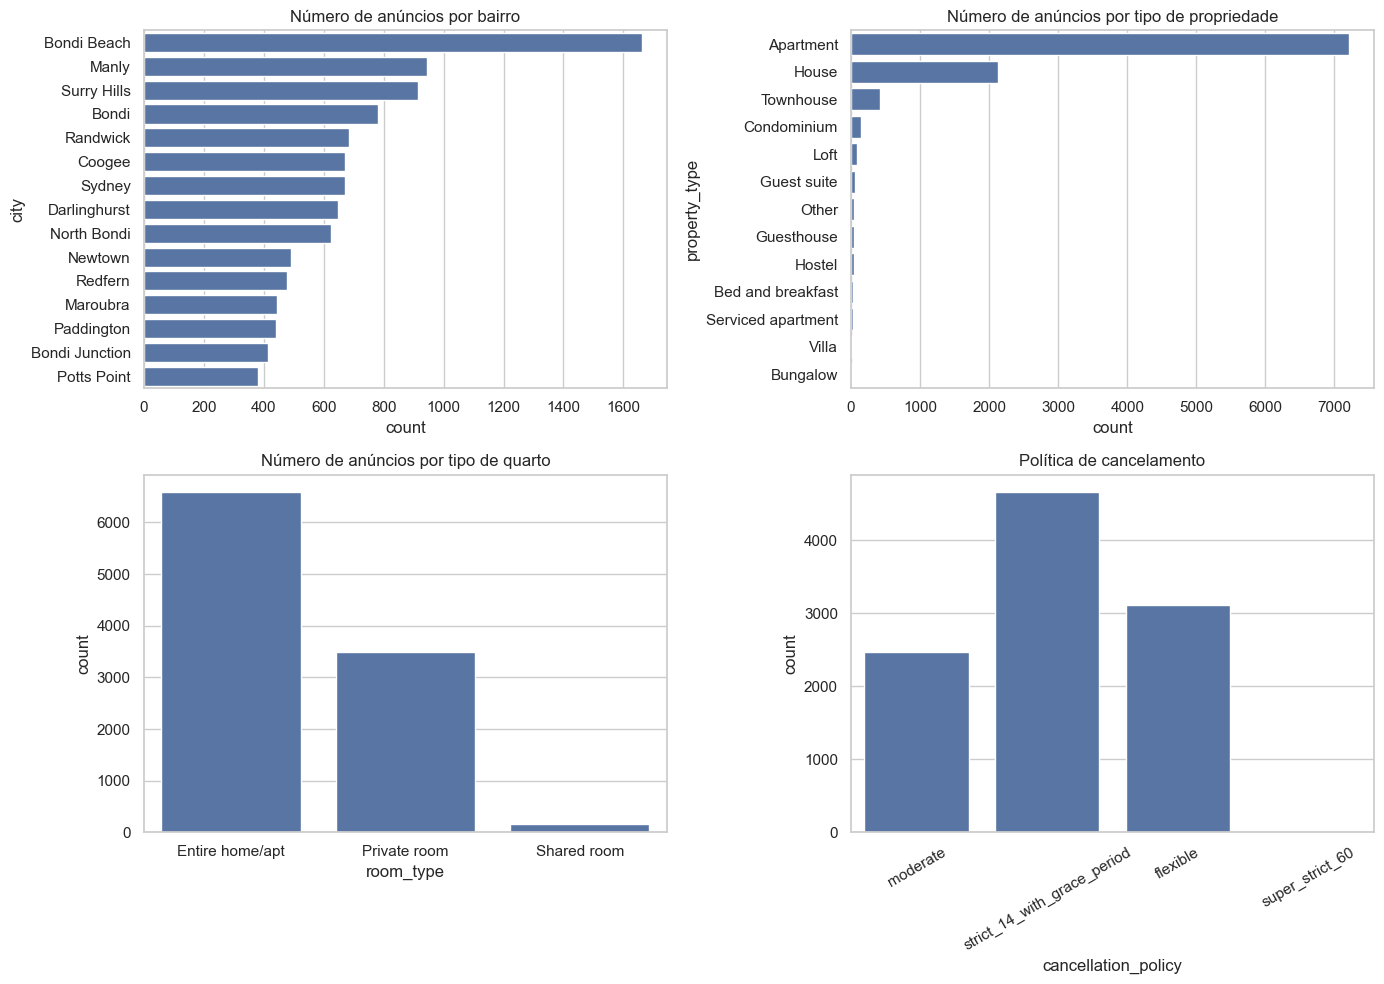

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, y="city", order=df["city"].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Número de anúncios por bairro")

sns.countplot(data=df, y="property_type", order=df["property_type"].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title("Número de anúncios por tipo de propriedade")

sns.countplot(data=df, x="room_type", order=df["room_type"].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title("Número de anúncios por tipo de quarto")

sns.countplot(data=df, x="cancellation_policy", ax=axes[1, 1])
axes[1, 1].set_title("Política de cancelamento")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

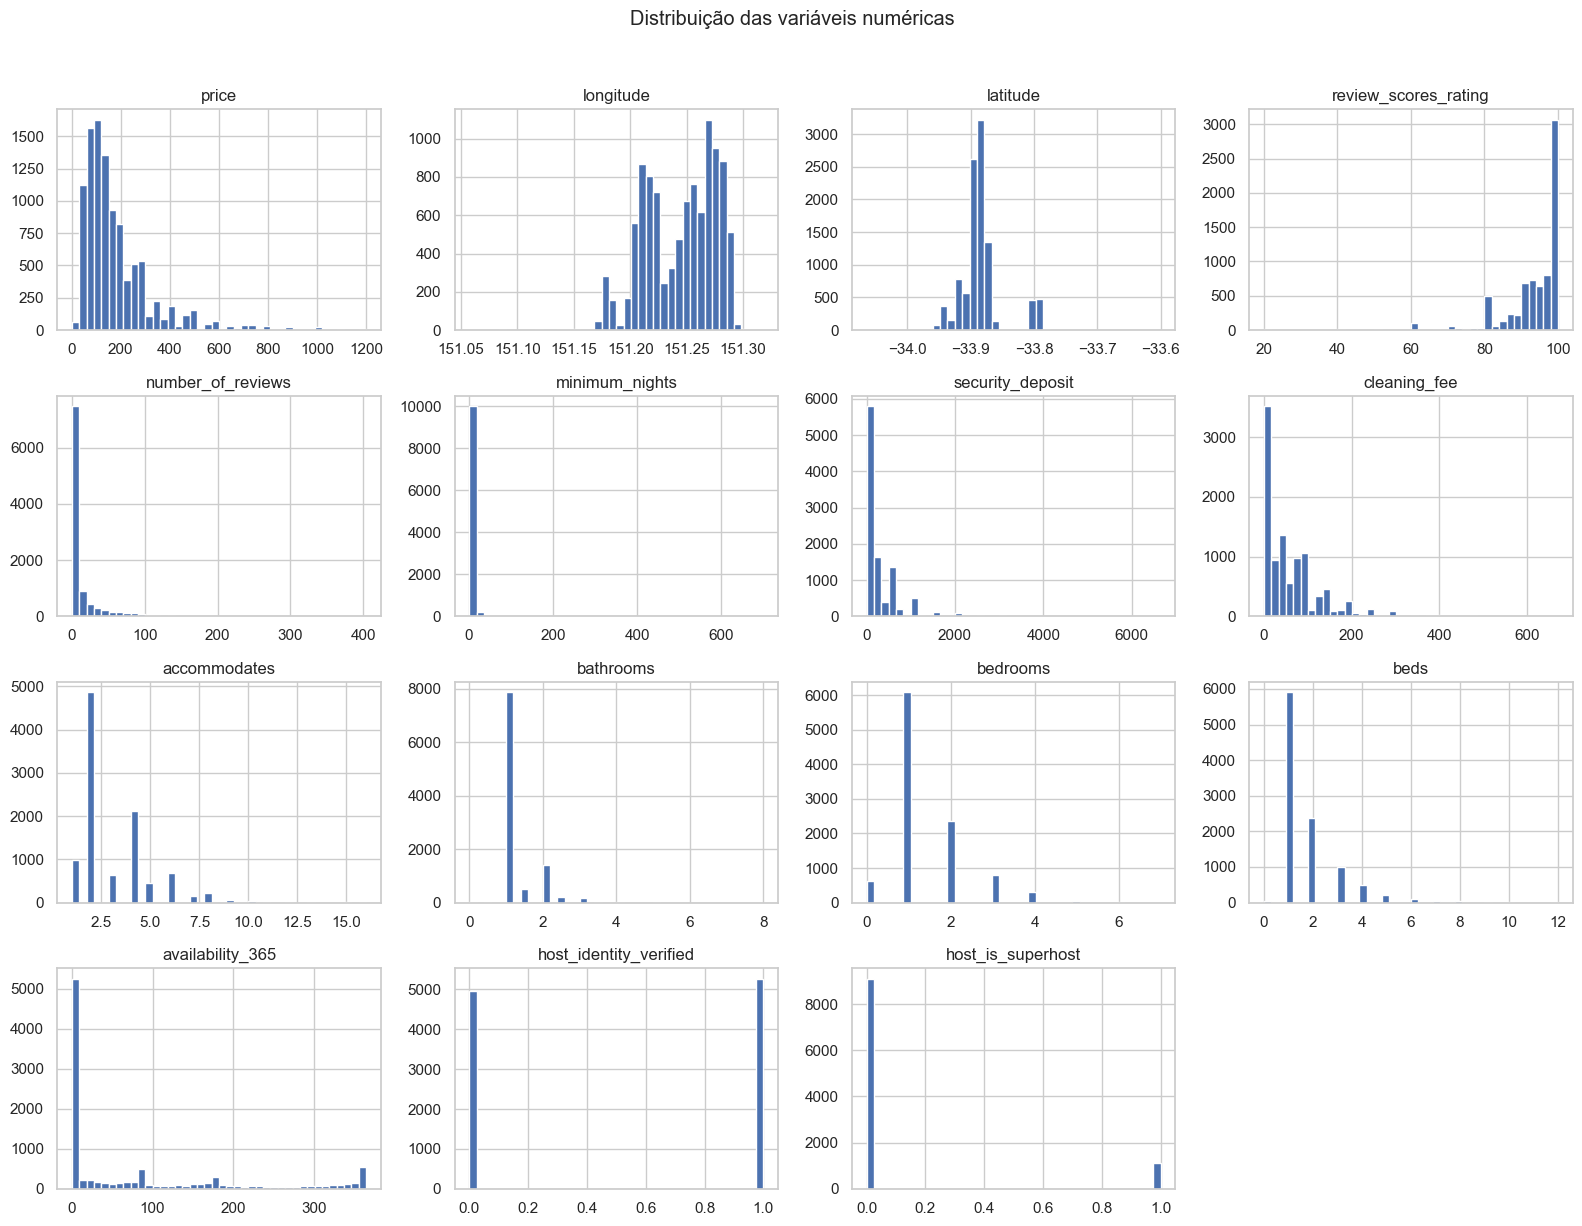

In [60]:
# Histogramas de todas as variáveis numéricas de uma vez, para termos uma visão geral
# rápida das distribuições (escalas, presença de assimetria, valores concentrados em 0, etc.)
df.select_dtypes(include=[np.number]).hist(bins=40, figsize=(16, 12))
plt.suptitle("Distribuição das variáveis numéricas", y=1.02)
plt.tight_layout()
plt.show()

### Preço médio por bairro

Uma primeira olhada em quanto o bairro (`city`) já explica sozinho sobre o preço — esperamos que
seja uma variável bastante relevante, já que Sydney tem bairros muito diferentes em termos de
valorização imobiliária.

In [61]:
preco_por_bairro = df.groupby("city")["price"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
preco_por_bairro.style.format({"mean": "{:.0f}", "median": "{:.0f}"})

,mean,median,count
city,,,
North Bondi,254,166,624
Manly,238,179,943
Paddington,215,150,440
Bondi Beach,193,150,1662
Sydney,192,166,670
Coogee,191,150,671
Bondi,178,128,782
Bondi Junction,176,130,415
Darlinghurst,170,148,646


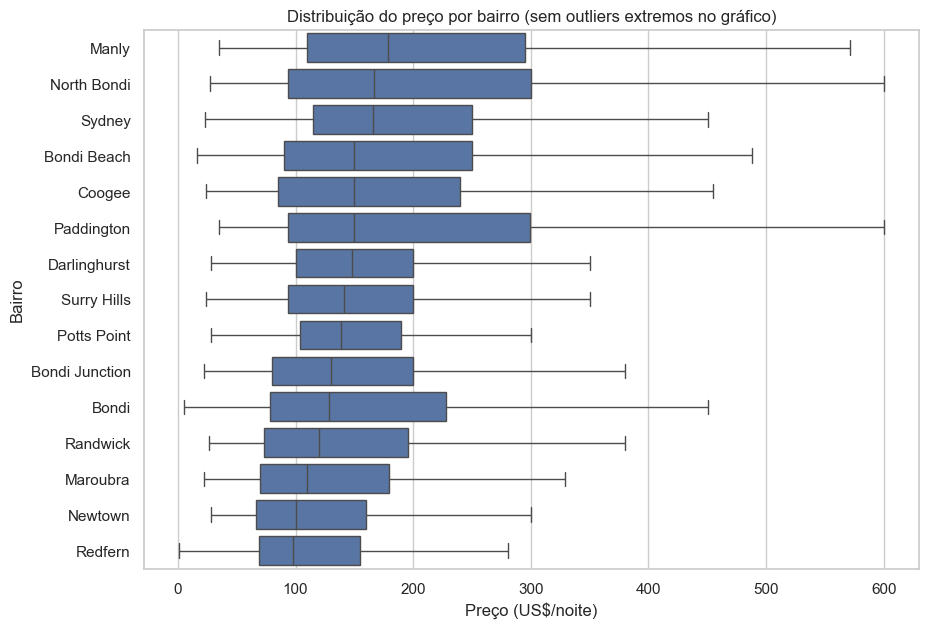

In [62]:
plt.figure(figsize=(10, 7))
ordem = df.groupby("city")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, y="city", x="price", order=ordem, showfliers=False)
plt.title("Distribuição do preço por bairro (sem outliers extremos no gráfico)")
plt.xlabel("Preço (US$/noite)")
plt.ylabel("Bairro")
plt.show()

### Mapa geográfico dos anúncios

Como temos latitude e longitude, podemos literalmente "desenhar" um mapa de Sydney usando os
próprios pontos de dados. O tamanho de cada ponto representa o número de avaliações (proxy de
popularidade) e a cor representa o preço.

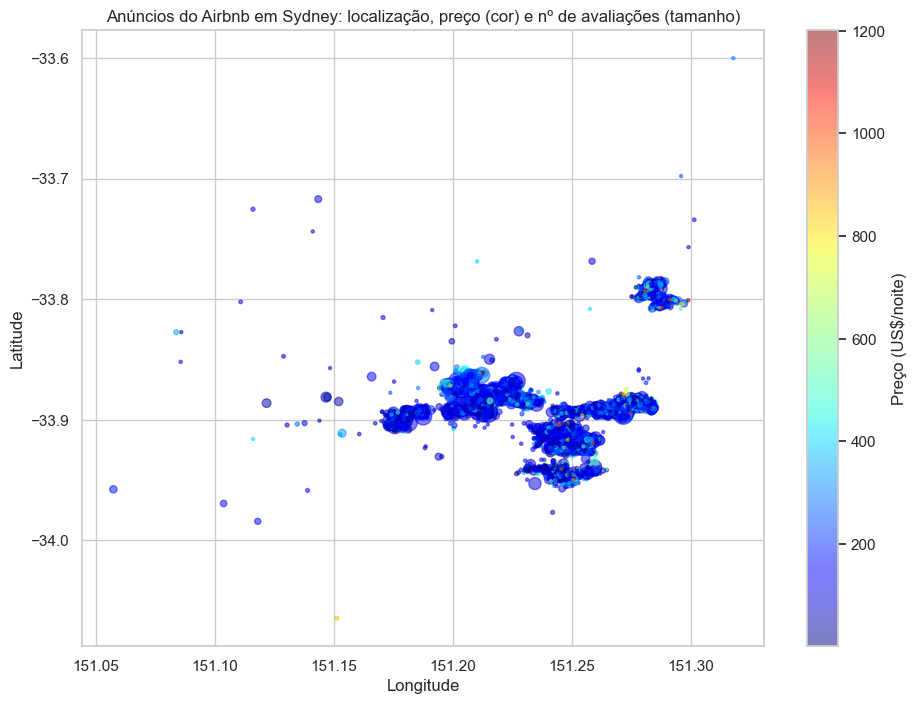

In [63]:
fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    df["longitude"], df["latitude"],
    c=df["price"], cmap="jet",
    s=df["number_of_reviews"] / 2 + 5,
    alpha=0.5,
)
plt.colorbar(scatter, label="Preço (US$/noite)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Anúncios do Airbnb em Sydney: localização, preço (cor) e nº de avaliações (tamanho)")
plt.show()

### Matriz de correlação

Vamos olhar a correlação linear (Pearson) entre as variáveis numéricas e o preço. É importante
lembrar que correlação **não implica causalidade** e captura apenas relações **lineares** — uma
variável pode ser muito relevante para o preço de forma não-linear e ainda assim ter correlação
linear baixa.

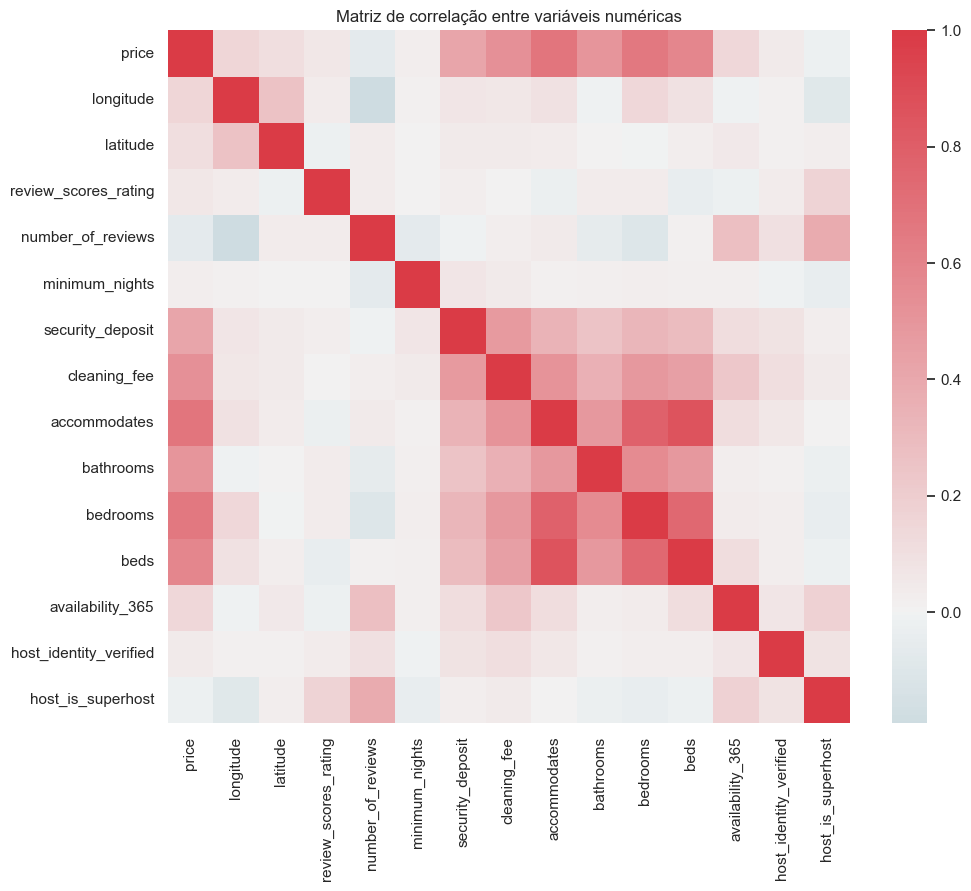

In [64]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=False, cmap=sns.diverging_palette(220, 10, as_cmap=True), center=0)
plt.title("Matriz de correlação entre variáveis numéricas")
plt.show()

In [65]:
corr_matrix["price"].sort_values(ascending=False)

price                     1.000000
accommodates              0.671161
bedrooms                  0.663715
beds                      0.584826
cleaning_fee              0.527779
bathrooms                 0.505784
security_deposit          0.419949
longitude                 0.149979
availability_365          0.146705
latitude                  0.107162
review_scores_rating      0.060386
host_identity_verified    0.046363
minimum_nights            0.024860
host_is_superhost        -0.015189
number_of_reviews        -0.063836
Name: price, dtype: float64

Como esperado, variáveis relacionadas ao **tamanho do imóvel** (`accommodates`, `bedrooms`,
`bathrooms`, `beds`) e ao valor de outras taxas cobradas (`cleaning_fee`, `security_deposit`) têm
as correlações positivas mais fortes com o preço. Vamos visualizar algumas dessas relações
diretamente.

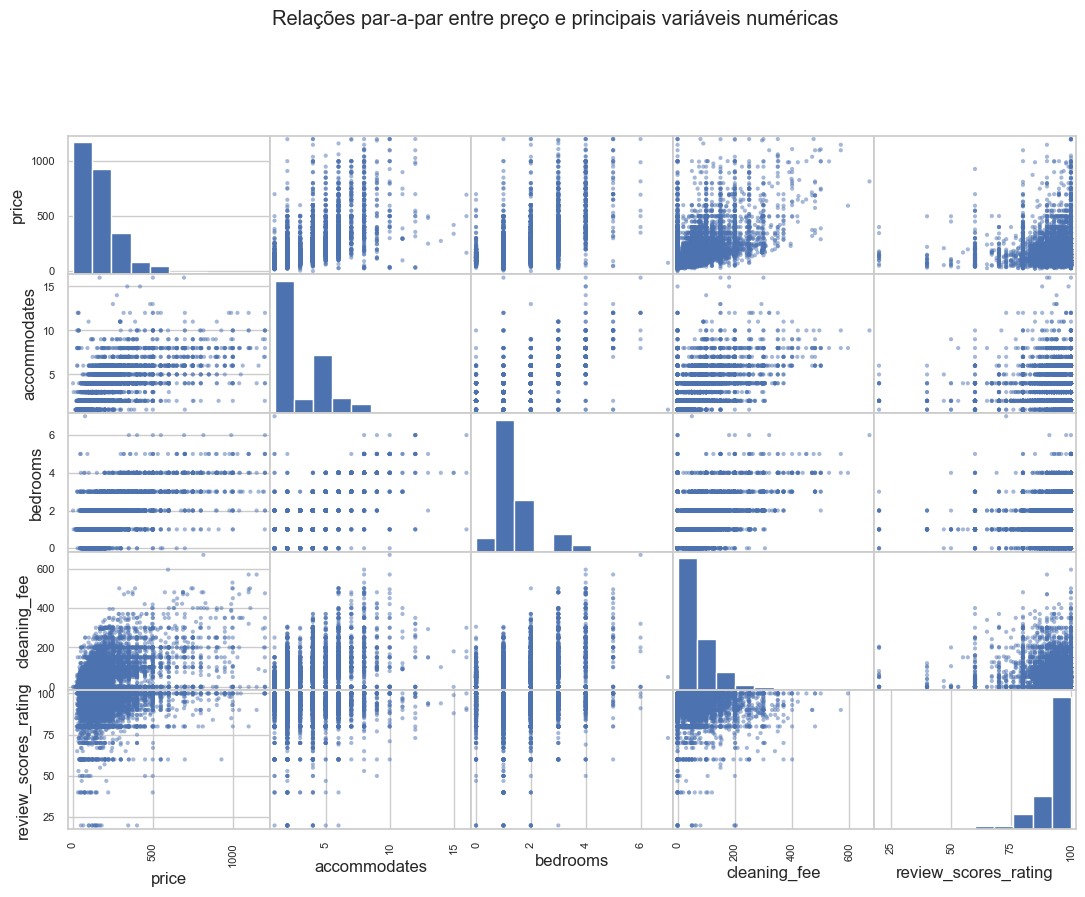

In [66]:
from pandas.plotting import scatter_matrix

attrs = ["price", "accommodates", "bedrooms", "cleaning_fee", "review_scores_rating"]
scatter_matrix(df[attrs], figsize=(13, 9), diagonal="hist")
plt.suptitle("Relações par-a-par entre preço e principais variáveis numéricas", y=1.02)
plt.show()

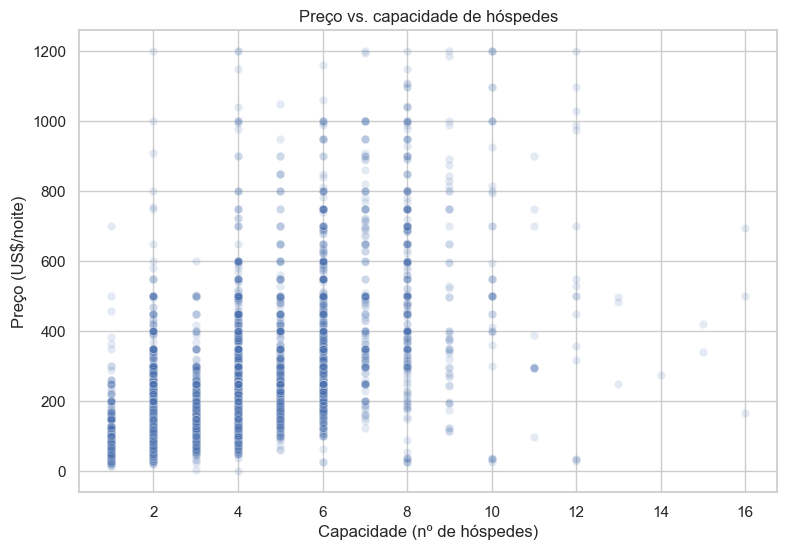

In [67]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="accommodates", y="price", alpha=0.15)
plt.title("Preço vs. capacidade de hóspedes")
plt.xlabel("Capacidade (nº de hóspedes)")
plt.ylabel("Preço (US$/noite)")
plt.show()

## 6. Divisão treino/teste estratificada

Antes de tomar qualquer decisão de modelagem (engenharia de atributos, escolha de modelo,
ajuste de hiperparâmetros), separamos uma fatia dos dados, o **conjunto de teste**, que só
será utilizada no final, para uma avaliação do modelo final. Isso simula a situação real
de usar o modelo em imóveis que ele nunca viu.

Em vez de uma divisão puramente aleatória (`train_test_split` simples), usamos
`StratifiedShuffleSplit` estratificando por **bairro (`city`)**. Isso garante que a proporção de
cada bairro seja aproximadamente a mesma no treino e no teste. Importante porque já vimos que o
bairro é fortemente associado ao preço, e uma divisão puramente aleatória poderia, por azar,
deixar algum bairro sub- ou super-representado em um dos dois conjuntos.

In [70]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

for train_idx, test_idx in splitter.split(df, df["city"]):
    strat_train_set = df.loc[train_idx].reset_index(drop=True)
    strat_test_set = df.loc[test_idx].reset_index(drop=True)

print(f"Conjunto de treino: {strat_train_set.shape[0]} linhas")
print(f"Conjunto de teste:  {strat_test_set.shape[0]} linhas")

Conjunto de treino: 8192 linhas
Conjunto de teste:  2049 linhas


In [71]:
# Conferindo que a proporção de cada bairro é semelhante em treino e teste
comparacao = pd.DataFrame({
    "dataset completo (%)": df["city"].value_counts(normalize=True) * 100,
    "treino (%)": strat_train_set["city"].value_counts(normalize=True) * 100,
    "teste (%)": strat_test_set["city"].value_counts(normalize=True) * 100,
}).round(2)
comparacao

,dataset completo (%),treino (%),teste (%)
city,,,
Bondi Beach,16.23,16.22,16.25
Manly,9.21,9.20,9.22
Surry Hills,8.94,8.95,8.93
Bondi,7.64,7.64,7.61
Randwick,6.67,6.67,6.69
Coogee,6.55,6.56,6.54
Sydney,6.54,6.54,6.54
Darlinghurst,6.31,6.31,6.30
North Bondi,6.09,6.09,6.10


A partir daqui, **todo** o trabalho de exploração adicional e de decisões de modelagem
(engenharia de atributos, comparação de modelos, ajuste de hiperparâmetros) é feito **apenas**
sobre `strat_train_set`. O `strat_test_set` fica "trancado" até a Seção 13.

## 7. Engenharia de atributos

Além das variáveis originais, algumas combinações costumam carregar mais informação preditiva do
que as variáveis isoladas. Criamos:

- **`bedrooms_per_person`** e **`bathrooms_per_person`**: quartos/banheiros por hóspede
  acomodado — captura o quão "espaçoso" ou "luxuoso" é o imóvel relativo à sua capacidade (uma
  casa com 5 quartos para 10 pessoas é bem diferente de uma com 1 quarto para 10 pessoas).
- **`past_and_future_popularity`**: número de avaliações dividido por (disponibilidade futura +
  1) — um *proxy* de o quanto o imóvel é "procurado": muitas avaliações passadas e pouca
  disponibilidade futura sugerem um imóvel que está sempre ocupado.
- **`has_reviews`**: indicador binário (visto na Seção 4.5) de que o imóvel já recebeu pelo menos
  uma avaliação.
- **`days_on_airbnb`**: há quantos dias o anfitrião está na plataforma, medido a partir de uma
  **data de referência fixa**. Note que usamos uma data fixa (`2018-07-01`, compatível com a
  época de coleta destes dados) e **não** `hoje()` — se usássemos a data atual do computador, o
  valor dessa variável (e, portanto, os resultados do notebook) mudariam toda vez que o notebook
  fosse executado novamente, o que quebraria a reprodutibilidade.

Encapsulamos essa lógica em uma função `engineer_features`, para garantir que exatamente a
**mesma transformação** seja aplicada ao treino, ao teste e, mais tarde, a qualquer novo imóvel
que quisermos avaliar (Seção 15).

In [72]:
# Data de referência fixa, coerente com a época de coleta dos dados (meados de 2018).
# Usar uma data fixa (em vez de `pd.Timestamp.today()`) é o que torna o notebook reprodutível.
REFERENCE_DATE = pd.Timestamp("2018-07-01")


def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    # Aplica a engenharia de atributos de forma consistente a qualquer DataFrame
    # que já tenha passado pela limpeza básica (colunas monetárias e host_since convertidas).
    data = data.copy()

    data["bedrooms_per_person"] = data["bedrooms"] / data["accommodates"]
    data["bathrooms_per_person"] = data["bathrooms"] / data["accommodates"]
    data["past_and_future_popularity"] = data["number_of_reviews"] / (data["availability_365"] + 1)
    data["has_reviews"] = (data["number_of_reviews"] > 0).astype(int)
    data["days_on_airbnb"] = (REFERENCE_DATE - data["host_since"]).dt.days

    # host_since já foi "resumida" em days_on_airbnb; a coluna de data em si
    # não é diretamente utilizável por um modelo numérico, então a removemos.
    data = data.drop(columns=["host_since"])

    return data


train_fe = engineer_features(strat_train_set)
test_fe = engineer_features(strat_test_set)

train_fe.head()

,price,city,longitude,latitude,review_scores_rating,number_of_reviews,minimum_nights,security_deposit,cleaning_fee,accommodates,bathrooms,bedrooms,beds,property_type,room_type,availability_365,host_identity_verified,host_is_superhost,cancellation_policy,bedrooms_per_person,bathrooms_per_person,past_and_future_popularity,has_reviews,days_on_airbnb
0,126.0,Bondi Junction,151.251857,-33.892782,NaN,0,2,0.0,30.0,5,2.0,2.0,1.0,Apartment,Entire home/apt,0,0.0,0.0,strict_14_with_grace_period,0.40,0.4000,0.000000,0,1303.0
1,150.0,Bondi Beach,151.267763,-33.888943,98.0,26,1,160.0,90.0,2,1.0,1.0,1.0,House,Entire home/apt,110,0.0,1.0,moderate,0.50,0.5000,0.234234,1,708.0
2,200.0,Surry Hills,151.212231,-33.881905,80.0,2,3,0.0,25.0,8,2.5,2.0,4.0,House,Entire home/apt,338,1.0,0.0,strict_14_with_grace_period,0.25,0.3125,0.005900,1,2185.0
3,300.0,Maroubra,151.251686,-33.948134,NaN,0,7,200.0,70.0,4,2.0,3.0,3.0,House,Entire home/apt,0,0.0,0.0,moderate,0.75,0.5000,0.000000,0,1625.0
4,150.0,Surry Hills,151.214295,-33.880141,NaN,1,5,400.0,0.0,2,1.0,0.0,1.0,Apartment,Entire home/apt,0,1.0,0.0,moderate,0.00,0.5000,1.000000,1,1019.0


In [73]:
# Vale checar rapidamente se as novas variáveis fazem sentido e não geraram
# valores inválidos (ex.: divisão por zero geraria +inf, que atrapalharia o modelo)
novas_vars = ["bedrooms_per_person", "bathrooms_per_person", "past_and_future_popularity", "days_on_airbnb"]
train_fe[novas_vars].describe()

,bedrooms_per_person,bathrooms_per_person,past_and_future_popularity,days_on_airbnb
count,8190.000000,8184.000000,8192.000000,8183.000000
mean,0.511070,0.501778,2.147251,1334.283270
std,0.265312,0.309965,7.842621,598.114622
min,0.000000,0.000000,0.000000,171.000000
25%,0.500000,0.312500,0.000000,905.000000
50%,0.500000,0.500000,0.159729,1310.000000
75%,0.500000,0.500000,1.000000,1742.000000
max,7.000000,8.000000,143.000000,3359.000000


## 8. Pipeline de pré-processamento para Machine Learning

Chegou a hora de preparar os dados no formato que os algoritmos de scikit-learn esperam: uma
matriz totalmente numérica, sem valores ausentes.

Separamos as colunas em dois grupos, que recebem tratamentos diferentes:

- **Numéricas**: imputação de valores ausentes pela **mediana** (robusta a outliers) seguida de
  **padronização** (`StandardScaler`, média 0 e desvio-padrão 1). Importante sobretudo para
  modelos lineares e regularizados, que são sensíveis à escala das variáveis.
- **Categóricas**: imputação pela **moda** (categoria mais frequente) seguida de
  **one-hot encoding** (`OneHotEncoder`), que transforma cada categoria em uma coluna binária.
  Usamos `handle_unknown="ignore"` para que, se uma categoria nova aparecer no teste (ou em um
  novo imóvel) que não existia no treino, o modelo simplesmente ignore-a (todas as colunas
  daquela variável ficam zero) em vez de gerar um erro.

Essas duas transformações são combinadas em um único `ColumnTransformer`, chamado aqui de
`preprocessor`. Crucialmente, **não vamos chamar `.fit()` nesse preprocessor separadamente** —
ele será o primeiro passo de cada `Pipeline` de modelo, para que a validação cruzada o treine
de forma correta em cada fold (ver nota metodológica na introdução).

In [74]:
X_train = train_fe.drop(columns=["price"])
y_train = train_fe["price"]

X_test = test_fe.drop(columns=["price"])
y_test = test_fe["price"]

# Identifica automaticamente quais colunas são numéricas e quais são categóricas (texto)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

print("Colunas numéricas   :", numeric_cols)
print("Colunas categóricas :", categorical_cols)

Colunas numéricas   : ['longitude', 'latitude', 'review_scores_rating', 'number_of_reviews', 'minimum_nights', 'security_deposit', 'cleaning_fee', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'availability_365', 'host_identity_verified', 'host_is_superhost', 'bedrooms_per_person', 'bathrooms_per_person', 'past_and_future_popularity', 'has_reviews', 'days_on_airbnb']
Colunas categóricas : ['city', 'property_type', 'room_type', 'cancellation_policy']


In [75]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

# Uma checagem rápida: ajustamos o preprocessor isoladamente só para
# inspecionar visualmente o formato dos dados transformados (não é assim
# que ele será usado durante a validação cruzada -- lá, ele fica dentro do Pipeline).
preview = preprocessor.fit_transform(X_train)
print(f"Formato dos dados após pré-processamento: {preview.shape}")
preview.head()

Formato dos dados após pré-processamento: (8192, 54)


,num__longitude,num__latitude,num__review_scores_rating,num__number_of_reviews,num__minimum_nights,num__security_deposit,num__cleaning_fee,num__accommodates,num__bathrooms,num__bedrooms,num__beds,num__availability_365,num__host_identity_verified,num__host_is_superhost,num__bedrooms_per_person,num__bathrooms_per_person,num__past_and_future_popularity,num__has_reviews,num__days_on_airbnb,cat__city_Bondi,cat__city_Bondi Beach,cat__city_Bondi Junction,cat__city_Coogee,cat__city_Darlinghurst,cat__city_Manly,cat__city_Maroubra,cat__city_Newtown,cat__city_North Bondi,cat__city_Paddington,cat__city_Potts Point,cat__city_Randwick,cat__city_Redfern,cat__city_Surry Hills,cat__city_Sydney,cat__property_type_Apartment,cat__property_type_Bed and breakfast,cat__property_type_Bungalow,cat__property_type_Condominium,cat__property_type_Guest suite,cat__property_type_Guesthouse,cat__property_type_Hostel,cat__property_type_House,cat__property_type_Loft,cat__property_type_Other,cat__property_type_Serviced apartment,cat__property_type_Townhouse,cat__property_type_Villa,cat__room_type_Entire home/apt,cat__room_type_Private room,cat__room_type_Shared room,cat__cancellation_policy_flexible,cat__cancellation_policy_moderate,cat__cancellation_policy_strict_14_with_grace_period,cat__cancellation_policy_super_strict_60
0,0.243471,-0.246077,0.251432,-0.454487,-0.220173,-0.559930,-0.446907,1.048147,1.489388,0.625927,-0.620399,-0.712613,-1.034784,-0.350219,-0.418704,-0.328529,-0.273809,-1.730924,-0.052290,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.751766,-0.130652,0.509058,0.335644,-0.301657,-0.226896,0.362475,-0.601396,-0.472514,-0.503002,-0.620399,0.210670,-1.034784,2.855359,-0.041720,-0.005735,-0.243941,0.577726,-1.047690,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-1.022746,0.080951,-1.809584,-0.393707,-0.138688,-0.559930,-0.514356,2.697690,2.470339,0.625927,1.786376,2.124383,0.966385,-0.350219,-0.984180,-0.610974,-0.273057,0.577726,1.423243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.238036,-1.910350,0.251432,-0.454487,0.187249,-0.143638,0.092681,0.498299,1.489388,1.754856,0.984118,-0.712613,-1.034784,-0.350219,0.900739,-0.005735,-0.273809,-1.730924,0.486396,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.956777,0.133996,0.251432,-0.424097,0.024280,0.272654,-0.851598,-0.601396,-0.472514,-1.631931,-0.620399,-0.712613,0.966385,-0.350219,-1.926640,-0.005735,-0.146293,0.577726,-0.527405,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


## 9. Modelos supervisionados de linha de base

Antes de partir para modelos mais sofisticados, é sempre bom estabelecer uma **linha de base**
simples. Vamos usar:

- **Regressão Linear**: o modelo mais simples possível — assume uma relação linear entre as
  variáveis e o preço, sem nenhuma regularização.
- **Árvore de Decisão**: um modelo não-linear capaz de capturar interações complexas entre
  variáveis, mas com tendência a **sobreajustar** (decorar o treino) se não for controlada.

Para avaliar de forma robusta, usamos **validação cruzada com 10 folds** (`KFold`, com
embaralhamento): os dados de treino são divididos em 10 partes; o modelo é treinado 10 vezes,
cada vez usando 9 partes para treinar e 1 parte diferente para validar. Isso dá uma estimativa de
erro muito mais confiável do que uma única divisão treino/validação, porque reduz a variância
associada a "ter sorte ou azar" numa divisão específica.

Métricas usadas:

- **RMSE** (*Root Mean Squared Error*): erro médio, na mesma unidade do preço (US\$), que penaliza
  mais fortemente erros grandes (por causa do termo ao quadrado).
- **MAE** (*Mean Absolute Error*): erro médio absoluto, também em US\$, mais fácil de interpretar
  e menos sensível a outliers do que o RMSE.
- **R²** (coeficiente de determinação): proporção da variância do preço que é explicada pelo
  modelo (1 = perfeito, 0 = equivalente a sempre prever a média).

In [76]:
cv = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# Guardamos os resultados de cada modelo neste dicionário, para comparar todos
# ao final da Seção 11 em uma única tabela.
cv_results = {}


def avaliar_modelo(nome, estimador, X=X_train, y=y_train, cv=cv, verbose=True):
    # Constrói um Pipeline (pré-processamento + modelo), roda validação cruzada
    # com múltiplas métricas de uma só vez e guarda/exibe o resultado resumido.
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimador),
    ])

    scores = cross_validate(
        pipeline, X, y, cv=cv, n_jobs=-1,
        scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    )

    resultado = {
        "RMSE_medio": -scores["test_neg_root_mean_squared_error"].mean(),
        "RMSE_desvio": scores["test_neg_root_mean_squared_error"].std(),
        "MAE_medio": -scores["test_neg_mean_absolute_error"].mean(),
        "R2_medio": scores["test_r2"].mean(),
    }
    cv_results[nome] = resultado

    if verbose:
        print(f"{nome}")
        print(f"  RMSE = {resultado['RMSE_medio']:.2f} (+/- {resultado['RMSE_desvio']:.2f})")
        print(f"  MAE  = {resultado['MAE_medio']:.2f}")
        print(f"  R2   = {resultado['R2_medio']:.3f}")

    return pipeline, scores


_ = avaliar_modelo("Regressão Linear", LinearRegression())

Regressão Linear
  RMSE = 96.66 (+/- 6.84)
  MAE  = 62.71
  R2   = 0.620


In [77]:
_ = avaliar_modelo("Árvore de Decisão", DecisionTreeRegressor(random_state=RANDOM_STATE))

Árvore de Decisão
  RMSE = 127.21 (+/- 8.86)
  MAE  = 77.12
  R2   = 0.340


Observe a diferença: a Árvore de Decisão (sem limite de profundidade) tem um desempenho
**pior** em validação cruzada do que a Regressão Linear, apesar de ser um modelo muito mais
flexível! Isso é o sintoma clássico de **sobreajuste (overfitting)**: a árvore consegue decorar
perfeitamente o conjunto de treino (erro de treino próximo de zero), mas essas decisões
extremamente específicas não generalizam bem para dados novos. Vamos confirmar isso comparando o
erro dentro da amostra (treino) com o erro de validação cruzada.

In [78]:
arvore_simples = DecisionTreeRegressor(random_state=RANDOM_STATE)
pipeline_arvore = Pipeline([("preprocessor", preprocessor), ("model", arvore_simples)])
pipeline_arvore.fit(X_train, y_train)

pred_treino = pipeline_arvore.predict(X_train)
rmse_treino = mean_squared_error(y_train, pred_treino) ** 0.5

print(f"RMSE dentro da amostra de treino: {rmse_treino:.2f}")
print(f"RMSE médio em validação cruzada:  {cv_results['Árvore de Decisão']['RMSE_medio']:.2f}")
print("\n=> O erro de treino é bem menor que o erro de validação: sinal claro de overfitting.")
print("   Isso motiva o uso de regularização (próxima seção) e/ou ensembles de árvores (Seção 11).")

RMSE dentro da amostra de treino: 0.00
RMSE médio em validação cruzada:  127.21

=> O erro de treino é bem menor que o erro de validação: sinal claro de overfitting.
   Isso motiva o uso de regularização (próxima seção) e/ou ensembles de árvores (Seção 11).


## 10. Regularização: Ridge, Lasso e Elastic Net

A Regressão Linear "pura" ajusta os coeficientes apenas minimizando o erro no treino, sem
nenhuma penalização sobre o tamanho desses coeficientes. Isso pode levar a coeficientes muito
grandes (instáveis) quando há variáveis correlacionadas entre si (colinearidade) ou quando há
muitas variáveis em relação ao número de observações — sintomas que favorecem overfitting.

**Regularização** consiste em adicionar, à função de custo, uma penalidade sobre o tamanho dos
coeficientes:

- **Ridge (penalidade L2)**: penaliza a **soma dos quadrados** dos coeficientes. Isso "encolhe"
  todos os coeficientes em direção a zero, mas raramente os zera por completo. Bom quando
  acreditamos que a maioria das variáveis contribui um pouco para o resultado.
- **Lasso (penalidade L1)**: penaliza a **soma dos valores absolutos** dos coeficientes. Uma
  propriedade importante do Lasso é que ele pode zerar completamente coeficientes de variáveis
  pouco relevantes, funcionando também como um método de **seleção automática de variáveis**.
- **Elastic Net**: combina as duas penalidades (L1 + L2), controlada por um parâmetro
  `l1_ratio` que varia de 0 (Ridge puro) a 1 (Lasso puro).

Em todos os casos, a força da penalização é controlada por um hiperparâmetro `alpha`
(quanto maior, mais forte a regularização, e mais os coeficientes são "encolhidos"). O valor
ideal de `alpha` não é conhecido a priori — vamos escolhê-lo via **busca em grade com validação
cruzada** (`GridSearchCV`), testando vários valores e escolhendo o que minimiza o RMSE médio nos
folds de validação.

**Importante:** regularização só faz sentido em conjunto com padronização das variáveis (já
incluída no nosso `preprocessor`), pois a penalidade é aplicada sobre a magnitude dos
coeficientes — se as variáveis estivessem em escalas muito diferentes (ex.: metros² vs. número
de quartos), a penalização afetaria as variáveis de forma desigual e arbitrária.

In [79]:
cv5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Ridge ---------------------------------------------------------------
ridge_pipeline = Pipeline([("preprocessor", preprocessor), ("model", Ridge())])
ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid={"model__alpha": [0.01, 0.1, 1, 10, 50, 100, 200, 500]},
    cv=cv5, scoring="neg_root_mean_squared_error", n_jobs=-1,
)
ridge_grid.fit(X_train, y_train)
print(f"[Ridge] melhor alpha = {ridge_grid.best_params_['model__alpha']}  |  RMSE (CV) = {-ridge_grid.best_score_:.2f}")

# --- Lasso -----------------------------------------------------------------
lasso_pipeline = Pipeline([("preprocessor", preprocessor), ("model", Lasso(max_iter=5000))])
lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid={"model__alpha": [0.01, 0.1, 0.5, 1, 5, 10, 50]},
    cv=cv5, scoring="neg_root_mean_squared_error", n_jobs=-1,
)
lasso_grid.fit(X_train, y_train)
print(f"[Lasso] melhor alpha = {lasso_grid.best_params_['model__alpha']}  |  RMSE (CV) = {-lasso_grid.best_score_:.2f}")

# --- Elastic Net -------------------------------------------------------------
elasticnet_pipeline = Pipeline([("preprocessor", preprocessor), ("model", ElasticNet(max_iter=5000))])
elasticnet_grid = GridSearchCV(
    elasticnet_pipeline,
    param_grid={"model__alpha": [0.1, 1, 10], "model__l1_ratio": [0.1, 0.5, 0.9]},
    cv=cv5, scoring="neg_root_mean_squared_error", n_jobs=-1,
)
elasticnet_grid.fit(X_train, y_train)
print(f"[Elastic Net] melhores params = {elasticnet_grid.best_params_}  |  RMSE (CV) = {-elasticnet_grid.best_score_:.2f}")

[Ridge] melhor alpha = 10  |  RMSE (CV) = 96.77
[Lasso] melhor alpha = 0.1  |  RMSE (CV) = 96.74
[Elastic Net] melhores params = {'model__alpha': 0.1, 'model__l1_ratio': 0.9}  |  RMSE (CV) = 96.82


In [80]:
# Registramos os três modelos regularizados (já com o melhor alpha encontrado)
# na mesma tabela de comparação usada para os modelos de linha de base.
_ = avaliar_modelo("Ridge (regularizado)", Ridge(alpha=ridge_grid.best_params_["model__alpha"]))
_ = avaliar_modelo("Lasso (regularizado)", Lasso(alpha=lasso_grid.best_params_["model__alpha"], max_iter=5000))
_ = avaliar_modelo(
    "Elastic Net (regularizado)",
    ElasticNet(
        alpha=elasticnet_grid.best_params_["model__alpha"],
        l1_ratio=elasticnet_grid.best_params_["model__l1_ratio"],
        max_iter=5000,
    ),
)

Ridge (regularizado)
  RMSE = 96.61 (+/- 6.77)
  MAE  = 62.62
  R2   = 0.620
Lasso (regularizado)
  RMSE = 96.59 (+/- 6.77)
  MAE  = 62.51
  R2   = 0.620
Elastic Net (regularizado)
  RMSE = 96.68 (+/- 6.72)
  MAE  = 62.39
  R2   = 0.619


### Visualizando o efeito da regularização sobre os coeficientes

Vamos comparar, lado a lado, os coeficientes ajustados pela Regressão Linear "pura", pelo Ridge
e pelo Lasso (todos com as variáveis já padronizadas, então os coeficientes são diretamente
comparáveis em magnitude). O objetivo é visualizar o **encolhimento (shrinkage)** causado pela
regularização e, especialmente no caso do Lasso, a **seleção de variáveis** (coeficientes que
vão a zero).

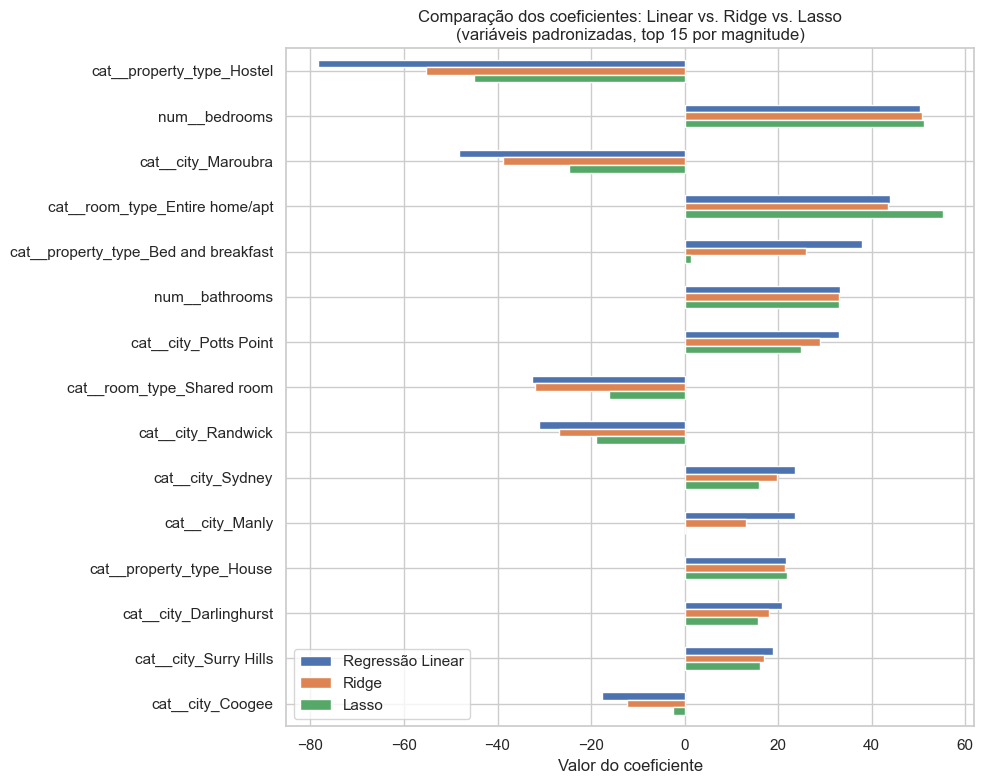


O Lasso zerou 14 de 54 coeficientes -- ou seja, descartou automaticamente 14 variáveis (após one-hot encoding).


In [81]:
# Ajustamos os três modelos no conjunto de treino inteiro (fora da validação cruzada)
# apenas para extrair e comparar os coeficientes finais.
linear_full = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())]).fit(X_train, y_train)
ridge_full = Pipeline([("preprocessor", preprocessor), ("model", Ridge(alpha=ridge_grid.best_params_["model__alpha"]))]).fit(X_train, y_train)
lasso_full = Pipeline([("preprocessor", preprocessor), ("model", Lasso(alpha=lasso_grid.best_params_["model__alpha"], max_iter=5000))]).fit(X_train, y_train)

feature_names = linear_full.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "Regressão Linear": linear_full.named_steps["model"].coef_,
    "Ridge": ridge_full.named_steps["model"].coef_,
    "Lasso": lasso_full.named_steps["model"].coef_,
}, index=feature_names)

# Ordenamos pela magnitude do coeficiente linear "puro" e olhamos as 15 variáveis mais fortes
top_features = coef_df["Regressão Linear"].abs().sort_values(ascending=False).head(15).index
coef_df.loc[top_features].plot(kind="barh", figsize=(10, 8))
plt.title("Comparação dos coeficientes: Linear vs. Ridge vs. Lasso\n(variáveis padronizadas, top 15 por magnitude)")
plt.xlabel("Valor do coeficiente")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

n_zerados = (lasso_full.named_steps["model"].coef_ == 0).sum()
print(f"\nO Lasso zerou {n_zerados} de {len(feature_names)} coeficientes "
      f"-- ou seja, descartou automaticamente {n_zerados} variáveis (após one-hot encoding).")

## 11. Modelos de ensemble e ajuste de hiperparâmetros

Vimos que uma única árvore de decisão sobreajusta facilmente. Uma forma clássica de resolver isso
é combinar várias árvores em um **ensemble**: a **Random Forest** treina dezenas ou centenas de
árvores, cada uma em uma amostra ligeiramente diferente dos dados (via *bootstrap*) e usando um
subconjunto aleatório de variáveis em cada divisão, e depois faz a **média das previsões**. Isso
reduz drasticamente a variância em relação a uma única árvore, mantendo a capacidade de capturar
relações não-lineares e interações entre variáveis.

Random Forests têm vários hiperparâmetros que afetam o equilíbrio entre viés e variância:

- `n_estimators`: número de árvores;
- `max_features`: número de variáveis consideradas em cada divisão de nó;
- `max_depth`: profundidade máxima de cada árvore;
- `min_samples_leaf`: número mínimo de observações exigido em cada folha.

Como o espaço de combinações possíveis é grande, usamos `RandomizedSearchCV`: em vez de testar
**todas** as combinações de uma grade (o que seria caro), sorteamos aleatoriamente um número fixo
de combinações (`n_iter`) e escolhemos a melhor encontrada — uma forma eficiente de explorar um
espaço de busca grande com um orçamento computacional limitado.

In [82]:
rf_pipeline = Pipeline([("preprocessor", preprocessor), ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])

param_distributions = {
    "model__n_estimators": randint(50, 300),
    "model__max_features": randint(2, 10),
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_leaf": randint(1, 8),
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    cv=cv5,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:")
for k, v in rf_search.best_params_.items():
    print(f"  {k.replace('model__', ''):18s} = {v}")
print(f"\nRMSE (CV, 5 folds) do melhor modelo: {-rf_search.best_score_:.2f}")

Melhores hiperparâmetros encontrados:
  max_depth          = 30
  max_features       = 9
  min_samples_leaf   = 1
  n_estimators       = 180

RMSE (CV, 5 folds) do melhor modelo: 90.15


In [83]:
# Registramos a Random Forest ajustada na mesma tabela comparativa,
# agora usando os 10 folds (para ficar consistente com os demais modelos).
melhores_params_rf = {k.replace("model__", ""): v for k, v in rf_search.best_params_.items()}
_ = avaliar_modelo(
    "Random Forest (ajustada)",
    RandomForestRegressor(**melhores_params_rf, random_state=RANDOM_STATE, n_jobs=-1),
)

Random Forest (ajustada)
  RMSE = 89.71 (+/- 7.80)
  MAE  = 54.74
  R2   = 0.673


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.

## 12. Comparação final de modelos (validação cruzada)

Reunimos os resultados de validação cruzada de todos os modelos testados em uma única tabela,
ordenada pelo RMSE médio (menor é melhor).

In [84]:
resumo = pd.DataFrame(cv_results).T
resumo = resumo.sort_values("RMSE_medio")
resumo.columns = ["RMSE médio (US$)", "Desvio-padrão do RMSE", "MAE médio (US$)", "R² médio"]
resumo.round(2)

,RMSE médio (US$),Desvio-padrão do RMSE,MAE médio (US$),R² médio
Random Forest (ajustada),89.71,7.80,54.74,0.67
Lasso (regularizado),96.59,6.77,62.51,0.62
Ridge (regularizado),96.61,6.77,62.62,0.62
Regressão Linear,96.66,6.84,62.71,0.62
Elastic Net (regularizado),96.68,6.72,62.39,0.62
Árvore de Decisão,127.21,8.86,77.12,0.34


t possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib worker

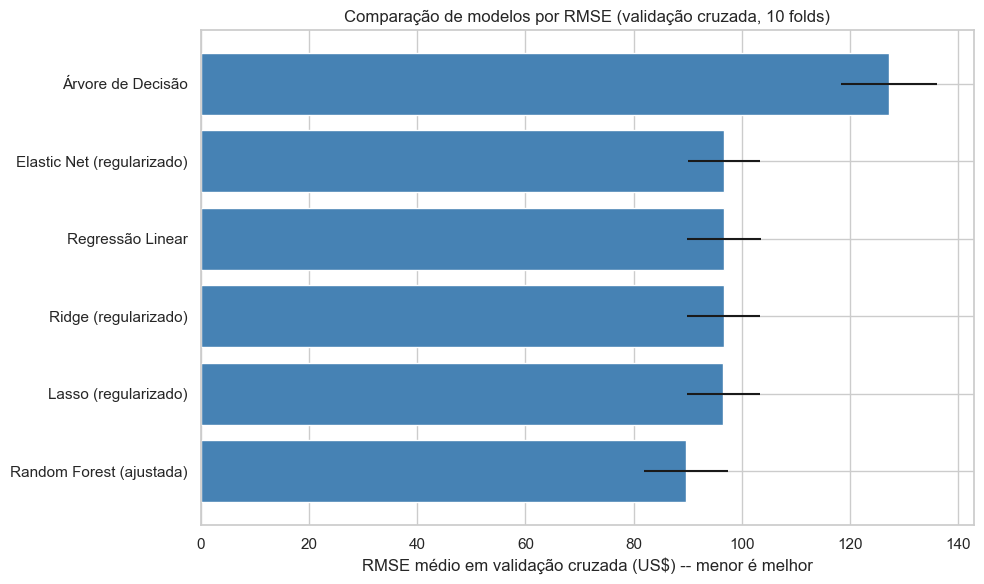

In [85]:
fig, ax = plt.subplots(figsize=(10, 6))
resumo_plot = resumo.sort_values("RMSE médio (US$)", ascending=True)
ax.barh(resumo_plot.index, resumo_plot["RMSE médio (US$)"], xerr=resumo_plot["Desvio-padrão do RMSE"], color="steelblue")
ax.set_xlabel("RMSE médio em validação cruzada (US$) -- menor é melhor")
ax.set_title("Comparação de modelos por RMSE (validação cruzada, 10 folds)")
plt.tight_layout()
plt.show()

**Leitura dos resultados:**

- A **Árvore de Decisão** isolada tem o pior desempenho, confirmando o diagnóstico de
  overfitting da Seção 9.
- **Ridge, Lasso e Elastic Net** têm desempenho muito parecido com a Regressão Linear "pura" —
  o que faz sentido, já que o dataset não é excessivamente colinear nem tem excesso de variáveis
  em relação ao número de observações, então o ganho da regularização aqui é discreto (embora
  ainda relevante para estabilidade dos coeficientes, como vimos na Seção 10).
- A **Random Forest** apresenta o melhor desempenho entre os modelos testados, com o menor RMSE
  e MAE e o maior R², justamente por capturar relações não-lineares e interações entre variáveis
  (ex.: o efeito de "número de quartos" sobre o preço provavelmente depende do bairro) sem sofrer
  do overfitting de uma árvore isolada, graças ao efeito de médias do ensemble.

Vamos adotar a **Random Forest ajustada** como modelo final e validá-la no conjunto de teste,
que ainda não foi tocado.

## 13. Avaliação no conjunto de teste

Esta é a etapa final e mais importante da validação: medir o desempenho do modelo escolhido em
dados **totalmente novos** (o conjunto de teste separado na Seção 6, que não influenciou nenhuma
decisão de modelagem até agora). Isso nos dá uma estimativa honesta de como o modelo se
comportaria em produção, avaliando um imóvel que ele nunca viu.

In [86]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(**melhores_params_rf, random_state=RANDOM_STATE, n_jobs=-1)),
])
final_model.fit(X_train, y_train)

test_predictions = final_model.predict(X_test)

test_rmse = mean_squared_error(y_test, test_predictions) ** 0.5
test_mae = mean_absolute_error(y_test, test_predictions)
test_r2 = r2_score(y_test, test_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)

print("Desempenho no conjunto de TESTE (dados nunca vistos pelo modelo):")
print(f"  RMSE = US$ {test_rmse:.2f}")
print(f"  MAE  = US$ {test_mae:.2f}")
print(f"  R²   = {test_r2:.3f}")
print(f"  MAPE = {test_mape:.1%}  (erro percentual médio)")

Desempenho no conjunto de TESTE (dados nunca vistos pelo modelo):
  RMSE = US$ 89.22
  MAE  = US$ 53.49
  R²   = 0.656
  MAPE = 33.0%  (erro percentual médio)


O desempenho no teste é muito próximo do desempenho estimado por validação cruzada na
Seção 12 — isso é um bom sinal de que a validação cruzada estava, de fato, estimando bem a
capacidade de generalização do modelo (e que não houve vazamento de informação em nenhuma etapa
anterior).

Vamos visualizar a qualidade das previsões de duas formas complementares: um gráfico de
**previsto vs. real**, e a distribuição dos **resíduos** (erro = valor real − valor previsto).

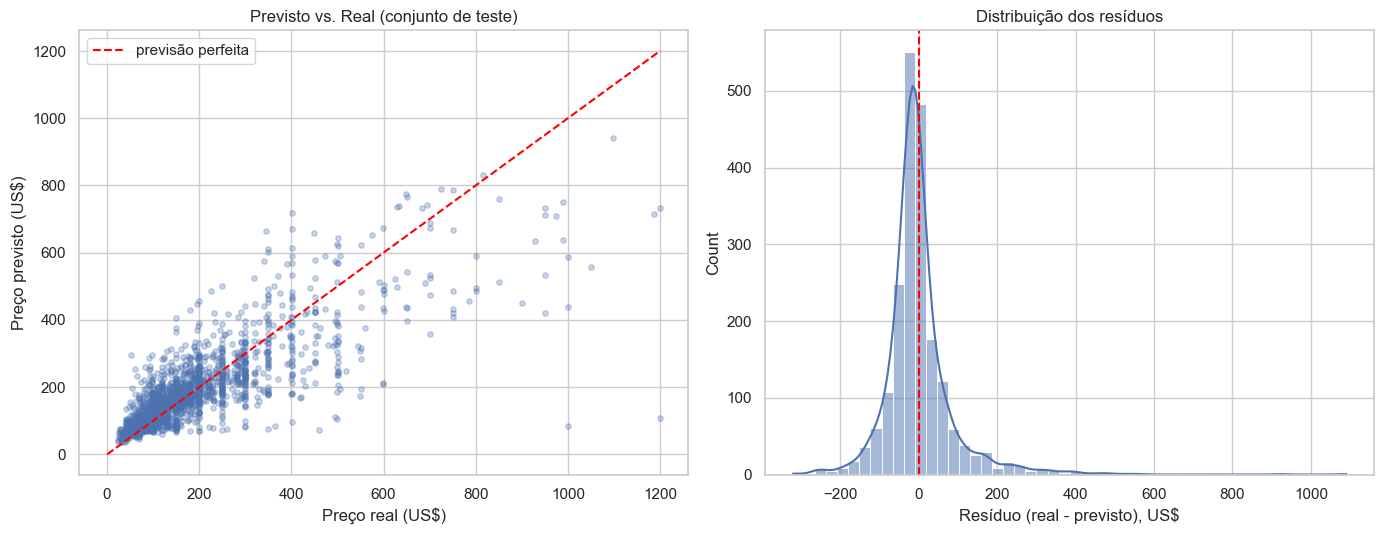

Resíduo médio: US$ 0.03  (idealmente próximo de 0, sem viés sistemático)


In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(y_test, test_predictions, alpha=0.3, s=15)
lims = [0, max(y_test.max(), test_predictions.max())]
axes[0].plot(lims, lims, color="red", linestyle="--", label="previsão perfeita")
axes[0].set_xlabel("Preço real (US$)")
axes[0].set_ylabel("Preço previsto (US$)")
axes[0].set_title("Previsto vs. Real (conjunto de teste)")
axes[0].legend()

residuos = y_test.values - test_predictions
sns.histplot(residuos, bins=50, ax=axes[1], kde=True)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Resíduo (real - previsto), US$")
axes[1].set_title("Distribuição dos resíduos")

plt.tight_layout()
plt.show()

print(f"Resíduo médio: US$ {residuos.mean():.2f}  (idealmente próximo de 0, sem viés sistemático)")

O gráfico de previsto vs. real mostra os pontos razoavelmente próximos da linha diagonal
(previsão perfeita), com maior dispersão nos imóveis mais caros — esperado, já que preços altos
são mais raros no treino e, portanto, mais difíceis de prever com precisão. Os resíduos estão
centrados perto de zero e com formato aproximadamente simétrico, sem um viés sistemático evidente
(o modelo não está, por exemplo, sistematicamente subestimando todos os preços).

## 14. Importância das variáveis

A Random Forest permite extrair a **importância de cada variável** (quanto, em média, cada
variável contribuiu para reduzir o erro nas árvores do ensemble). Isso é útil tanto para
interpretar o modelo quanto para validar se os resultados fazem sentido do ponto de vista de
negócio.

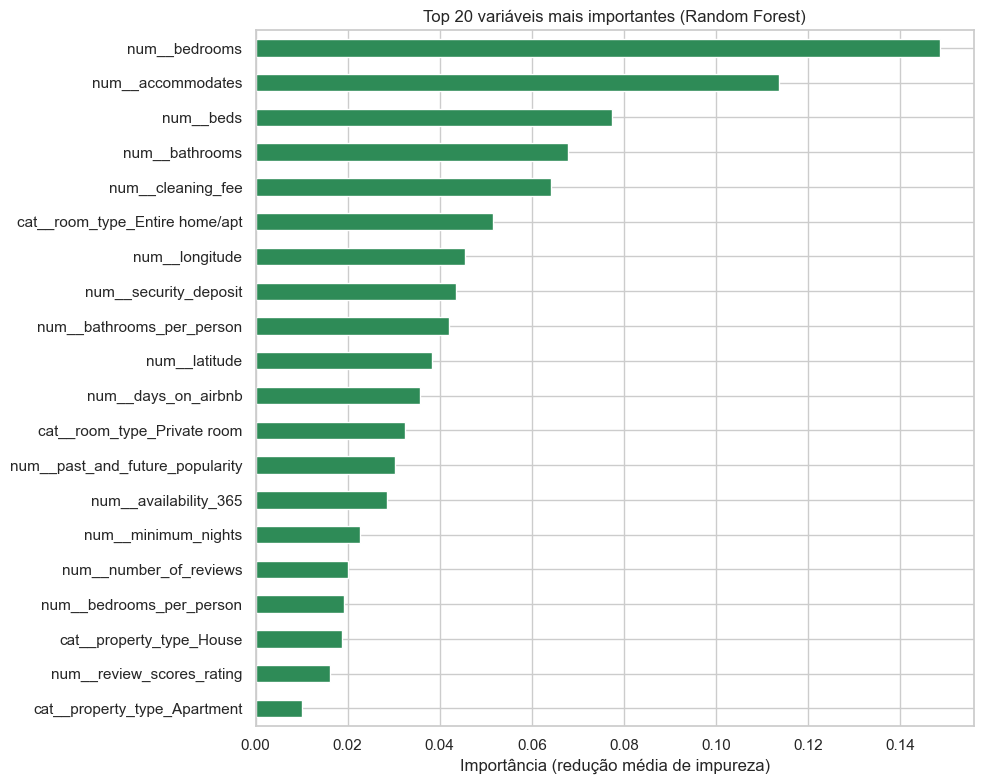

num__bedrooms                      0.148684
num__accommodates                  0.113691
num__beds                          0.077450
num__bathrooms                     0.067921
num__cleaning_fee                  0.064133
cat__room_type_Entire home/apt     0.051648
num__longitude                     0.045595
num__security_deposit              0.043489
num__bathrooms_per_person          0.041977
num__latitude                      0.038357
num__days_on_airbnb                0.035717
cat__room_type_Private room        0.032354
num__past_and_future_popularity    0.030290
num__availability_365              0.028598
num__minimum_nights                0.022684
num__number_of_reviews             0.020103
num__bedrooms_per_person           0.019212
cat__property_type_House           0.018736
num__review_scores_rating          0.016062
cat__property_type_Apartment       0.010049
dtype: float64

In [88]:
importances = final_model.named_steps["model"].feature_importances_
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_importance.head(20).sort_values().plot(kind="barh", color="seagreen")
plt.title("Top 20 variáveis mais importantes (Random Forest)")
plt.xlabel("Importância (redução média de impureza)")
plt.tight_layout()
plt.show()

feat_importance.head(20)

Como esperado a partir da análise de correlação (Seção 5), variáveis relacionadas ao
**tamanho do imóvel** (`bedrooms`, `accommodates`, `bathrooms`, `beds`) dominam a importância,
seguidas por variáveis comerciais (`cleaning_fee`, `security_deposit`) e o tipo de acomodação
(`room_type_Entire home/apt`, ou seja, alugar o imóvel inteiro vs. apenas um quarto). Localização
(`longitude`/`latitude`) e características do anfitrião (`days_on_airbnb`,
`past_and_future_popularity`) também aparecem, mas com peso individual menor — seu efeito
provavelmente já está parcialmente capturado pelas variáveis de bairro (`city`) e tamanho.

## 15. Aplicação prática: qual é o preço justo para o imóvel de Bondi Beach?

Voltamos ao problema de negócio que motivou este notebook: o anfitrião de Bondi Beach cobra
atualmente **US\$ 500** por noite. Vamos usar o modelo final para estimar quanto ele
**deveria** estar cobrando, dado o perfil do imóvel.

Características do imóvel (mesmas do enunciado original do caso):

- Anfitrião desde **agosto de 2010**
- Localização: `lon = 151.274506, lat = -33.889087` (Bondi Beach)
- Nota média das avaliações: **95**
- Número de avaliações: **53**
- Estadia mínima: **4 noites**
- Acomoda até **10 pessoas**, com **3 banheiros, 5 quartos e 7 camas**
- Taxa de limpeza: **US\$ 370**; depósito de segurança: **US\$ 1.500**
- Tipo de propriedade: **Casa** (`House`), imóvel inteiro (`Entire home/apt`)
- Disponível **255 de 365 dias**
- Anfitrião **verificado** e **superhost**
- Política de cancelamento: **estrita, com 14 dias de carência**

In [89]:
novo_imovel = pd.DataFrame([{
    "city": "Bondi Beach",
    "longitude": 151.274506,
    "latitude": -33.889087,
    "review_scores_rating": 95,
    "number_of_reviews": 53,
    "minimum_nights": 4,
    "security_deposit": 1500,
    "cleaning_fee": 370,
    "accommodates": 10,
    "bathrooms": 3,
    "bedrooms": 5,
    "beds": 7,
    "property_type": "House",
    "room_type": "Entire home/apt",
    "availability_365": 255,
    "host_identity_verified": 1,
    "host_is_superhost": 1,
    "cancellation_policy": "strict_14_with_grace_period",
    "host_since": pd.Timestamp("2010-08-01"),
}])

# Aplicamos exatamente a mesma função de engenharia de atributos usada no treino/teste,
# garantindo consistência total entre o que o modelo viu durante o treino e o que
# está recebendo agora para prever.
novo_imovel_fe = engineer_features(novo_imovel)
novo_imovel_fe

,city,longitude,latitude,review_scores_rating,number_of_reviews,minimum_nights,security_deposit,cleaning_fee,accommodates,bathrooms,bedrooms,beds,property_type,room_type,availability_365,host_identity_verified,host_is_superhost,cancellation_policy,bedrooms_per_person,bathrooms_per_person,past_and_future_popularity,has_reviews,days_on_airbnb
0,Bondi Beach,151.274506,-33.889087,95,53,4,1500,370,10,3,5,7,House,Entire home/apt,255,1,1,strict_14_with_grace_period,0.5,0.3,0.207031,1,2891


In [90]:
preco_atual = 500
preco_previsto = final_model.predict(novo_imovel_fe)[0]
diferenca = preco_previsto - preco_atual

print(f"Preço atualmente cobrado:  US$ {preco_atual:,.2f}")
print(f"Preço justo estimado:      US$ {preco_previsto:,.2f}")
print(f"Diferença sugerida:        US$ {diferenca:+,.2f}  ({diferenca / preco_atual:+.1%})")

if diferenca > 0:
    print("\n=> O modelo sugere que o anfitrião está cobrando ABAIXO do valor de mercado")
    print("   para um imóvel com essas características, e poderia aumentar o preço.")
else:
    print("\n=> O modelo sugere que o preço atual está ACIMA do valor de mercado")
    print("   para um imóvel com essas características.")

Preço atualmente cobrado:  US$ 500.00
Preço justo estimado:      US$ 678.74
Diferença sugerida:        US$ +178.74  (+35.7%)

=> O modelo sugere que o anfitrião está cobrando ABAIXO do valor de mercado
   para um imóvel com essas características, e poderia aumentar o preço.


> **Ressalva importante:** este imóvel específico (grande, 5 quartos, superhost, taxas
> altas) está no extremo superior da distribuição de preços observada no treino — a Seção 13
> mostrou que o modelo tem maior incerteza justamente nessa faixa de preços mais altos e mais
> raros. A estimativa deve, portanto, ser interpretada como uma referência de mercado, não como
> um valor definitivo — na prática, complementaríamos essa estimativa com um intervalo de
> confiança (por exemplo, usando a dispersão das previsões das árvores individuais da Random
> Forest) e com o julgamento de um especialista do mercado imobiliário local.

## 16. Resumo 

1. Limpamos um dataset real e "bagunçado" de anúncios do Airbnb (campos monetários como texto,
   outliers extremos, valores ausentes não-aleatórios, categorias raras).
2. Realizamos uma análise exploratória para entender a distribuição do preço e sua relação com
   localização, tamanho do imóvel e reputação do anfitrião.
3. Separamos treino e teste de forma estratificada **antes** de qualquer decisão de modelagem.
4. Criamos atributos derivados com justificativa de negócio (não só matemática).
5. Construímos um pipeline de pré-processamento (`ColumnTransformer`) integrado à validação
   cruzada, evitando vazamento de dados.
6. Comparamos modelos de complexidade crescente — Regressão Linear, modelos regularizados
   (Ridge/Lasso/Elastic Net), Árvore de Decisão e Random Forest — usando validação cruzada de
   10 folds e três métricas complementares (RMSE, MAE, R²).
7. Ajustamos hiperparâmetros via busca em grade (Ridge/Lasso/Elastic Net) e busca aleatória
   (Random Forest).
8. Avaliamos o modelo final, honestamente, em dados nunca vistos, e inspecionamos resíduos e
   importância de variáveis.
9. Aplicamos o modelo a um caso de negócio concreto.